In [1]:
%pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift
import time
notebook_start = time.perf_counter()

Obtaining file:///home/darshan/A6/PCSAFT_cDFT/thermoift
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for thermoift (pyproject.toml) ... done
  Created wheel for thermoift: filename=thermoift-0.2.0-0.editable-py3-none-any.whl size=1730 sha256=d5576620518ea0b29725072d6edb216d1b4ecf42769d78706d0e9e68a86d678d
  Stored in directory: /tmp/pip-ephem-wheel-cache-2bffzj73/wheels/fd/2f/c4/54a2ee5cd16a9bf5b183bbe5c28d1b3ba4926fb0261a13e1e4
Successfully built thermoift
  Attempting uninstall: thermoift
    Found existing installation: thermoift 0.2.0
    Uninstalling thermoift-0.2.0:
      Successfully uninstalled thermoift-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
import  os
import  json
import  pandas as pd
import  numpy as np
import  joblib
import  matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, MLPreprocessing
from    thermoift.rng_utils import get_rng
from    thermoift import plot_correlation_heatmap, print_model_metrics
from    sklearn.preprocessing import StandardScaler
from    sklearn.model_selection import train_test_split, cross_val_score
from    sklearn.gaussian_process import GaussianProcessRegressor
from    sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from    sklearn.pipeline import Pipeline

In [3]:
OUTPUT_FOLDER           = "GPR_RESIDUAL_OUTPUTS"
SEED                    = 4555525
EXPERIMENT_MAX_SAMPLES  = 2000  # Set to None to use the full dataset

In [4]:
df          = pd.read_csv("1691761_CombinedDataset_A3.csv")
df.columns  = [col.strip().replace(" ", "_") for col in df.columns]

# Mixture CO2 partial density gap
df["NUM1"] = df["rhoL_carbon_dioxide"] - df["rhoV_carbon_dioxide"]
df["DEN1"] = df["rhoL0_carbon_dioxide"] - df["rhoV0_carbon_dioxide"]

# Reference density-gap ratio
df["r1"] = df["NUM1"] / df["DEN1"]
df["r1sq"] = df["r1"] ** 2

# WSD baseline if only CO2 contributes
# gamma_base = gamma0_CO2 * r1^2
df["gamma_base"] = df["gamma0_carbon_dioxide"] * df["r1sq"]
df["gamma_cDFT"] = df["gamma_wsd"] + df["gamma_cDFT_minus_wsd_uncorrected"]

# Target : Relative residual vs baseline
df = df.dropna(subset=["gamma_cDFT", "gamma_base"]).copy()
df["residual"] = df["gamma_cDFT"] - df["gamma_base"]

if EXPERIMENT_MAX_SAMPLES is not None:
    df = df.sample(n=min(EXPERIMENT_MAX_SAMPLES, len(df)), random_state=SEED).copy()
    df = df.reset_index(drop=True)

print(f"Total active samples: {len(df)}")
print(f"Experiment sample cap: {EXPERIMENT_MAX_SAMPLES}")
print(f"\nResidual statistics:")
print(df["residual"].describe())

Total active samples: 2000
Experiment sample cap: 2000

Residual statistics:
count    2000.000000
mean       -0.410891
std         0.868157
min        -5.517356
25%        -0.670284
50%        -0.246706
75%        -0.055272
max         5.723166
Name: residual, dtype: float64


In [5]:
target     = "residual"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
DROP_FEATURES = ["z_oxygen"]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any() and col not in DROP_FEATURES]
features   = ["T", "P"] + Z_non_zero

print(f"Selected features: {features}")

X           = df[features]
y           = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

# Working dataframe has already been reduced above when EXPERIMENT_MAX_SAMPLES is set

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:      {X_test.shape[0]}")
print(f"Validation samples:   {X_val.shape[0]}")

Selected features: ['T', 'P', 'z_argon', 'z_carbon_dioxide', 'z_carbon_monoxide', 'z_hydrogen', 'z_hydrogen_sulfide', 'z_methane', 'z_nitrogen']

Training samples:   1400
Testing samples:      300
Validation samples:   300


Feature correlations with residual:
z_hydrogen_sulfide    0.516997
T                     0.325322
z_carbon_dioxide      0.180466
z_methane            -0.009019
P                    -0.085929
z_argon              -0.117991
z_nitrogen           -0.149378
z_carbon_monoxide    -0.205926
z_hydrogen           -0.247908
Name: residual, dtype: float64


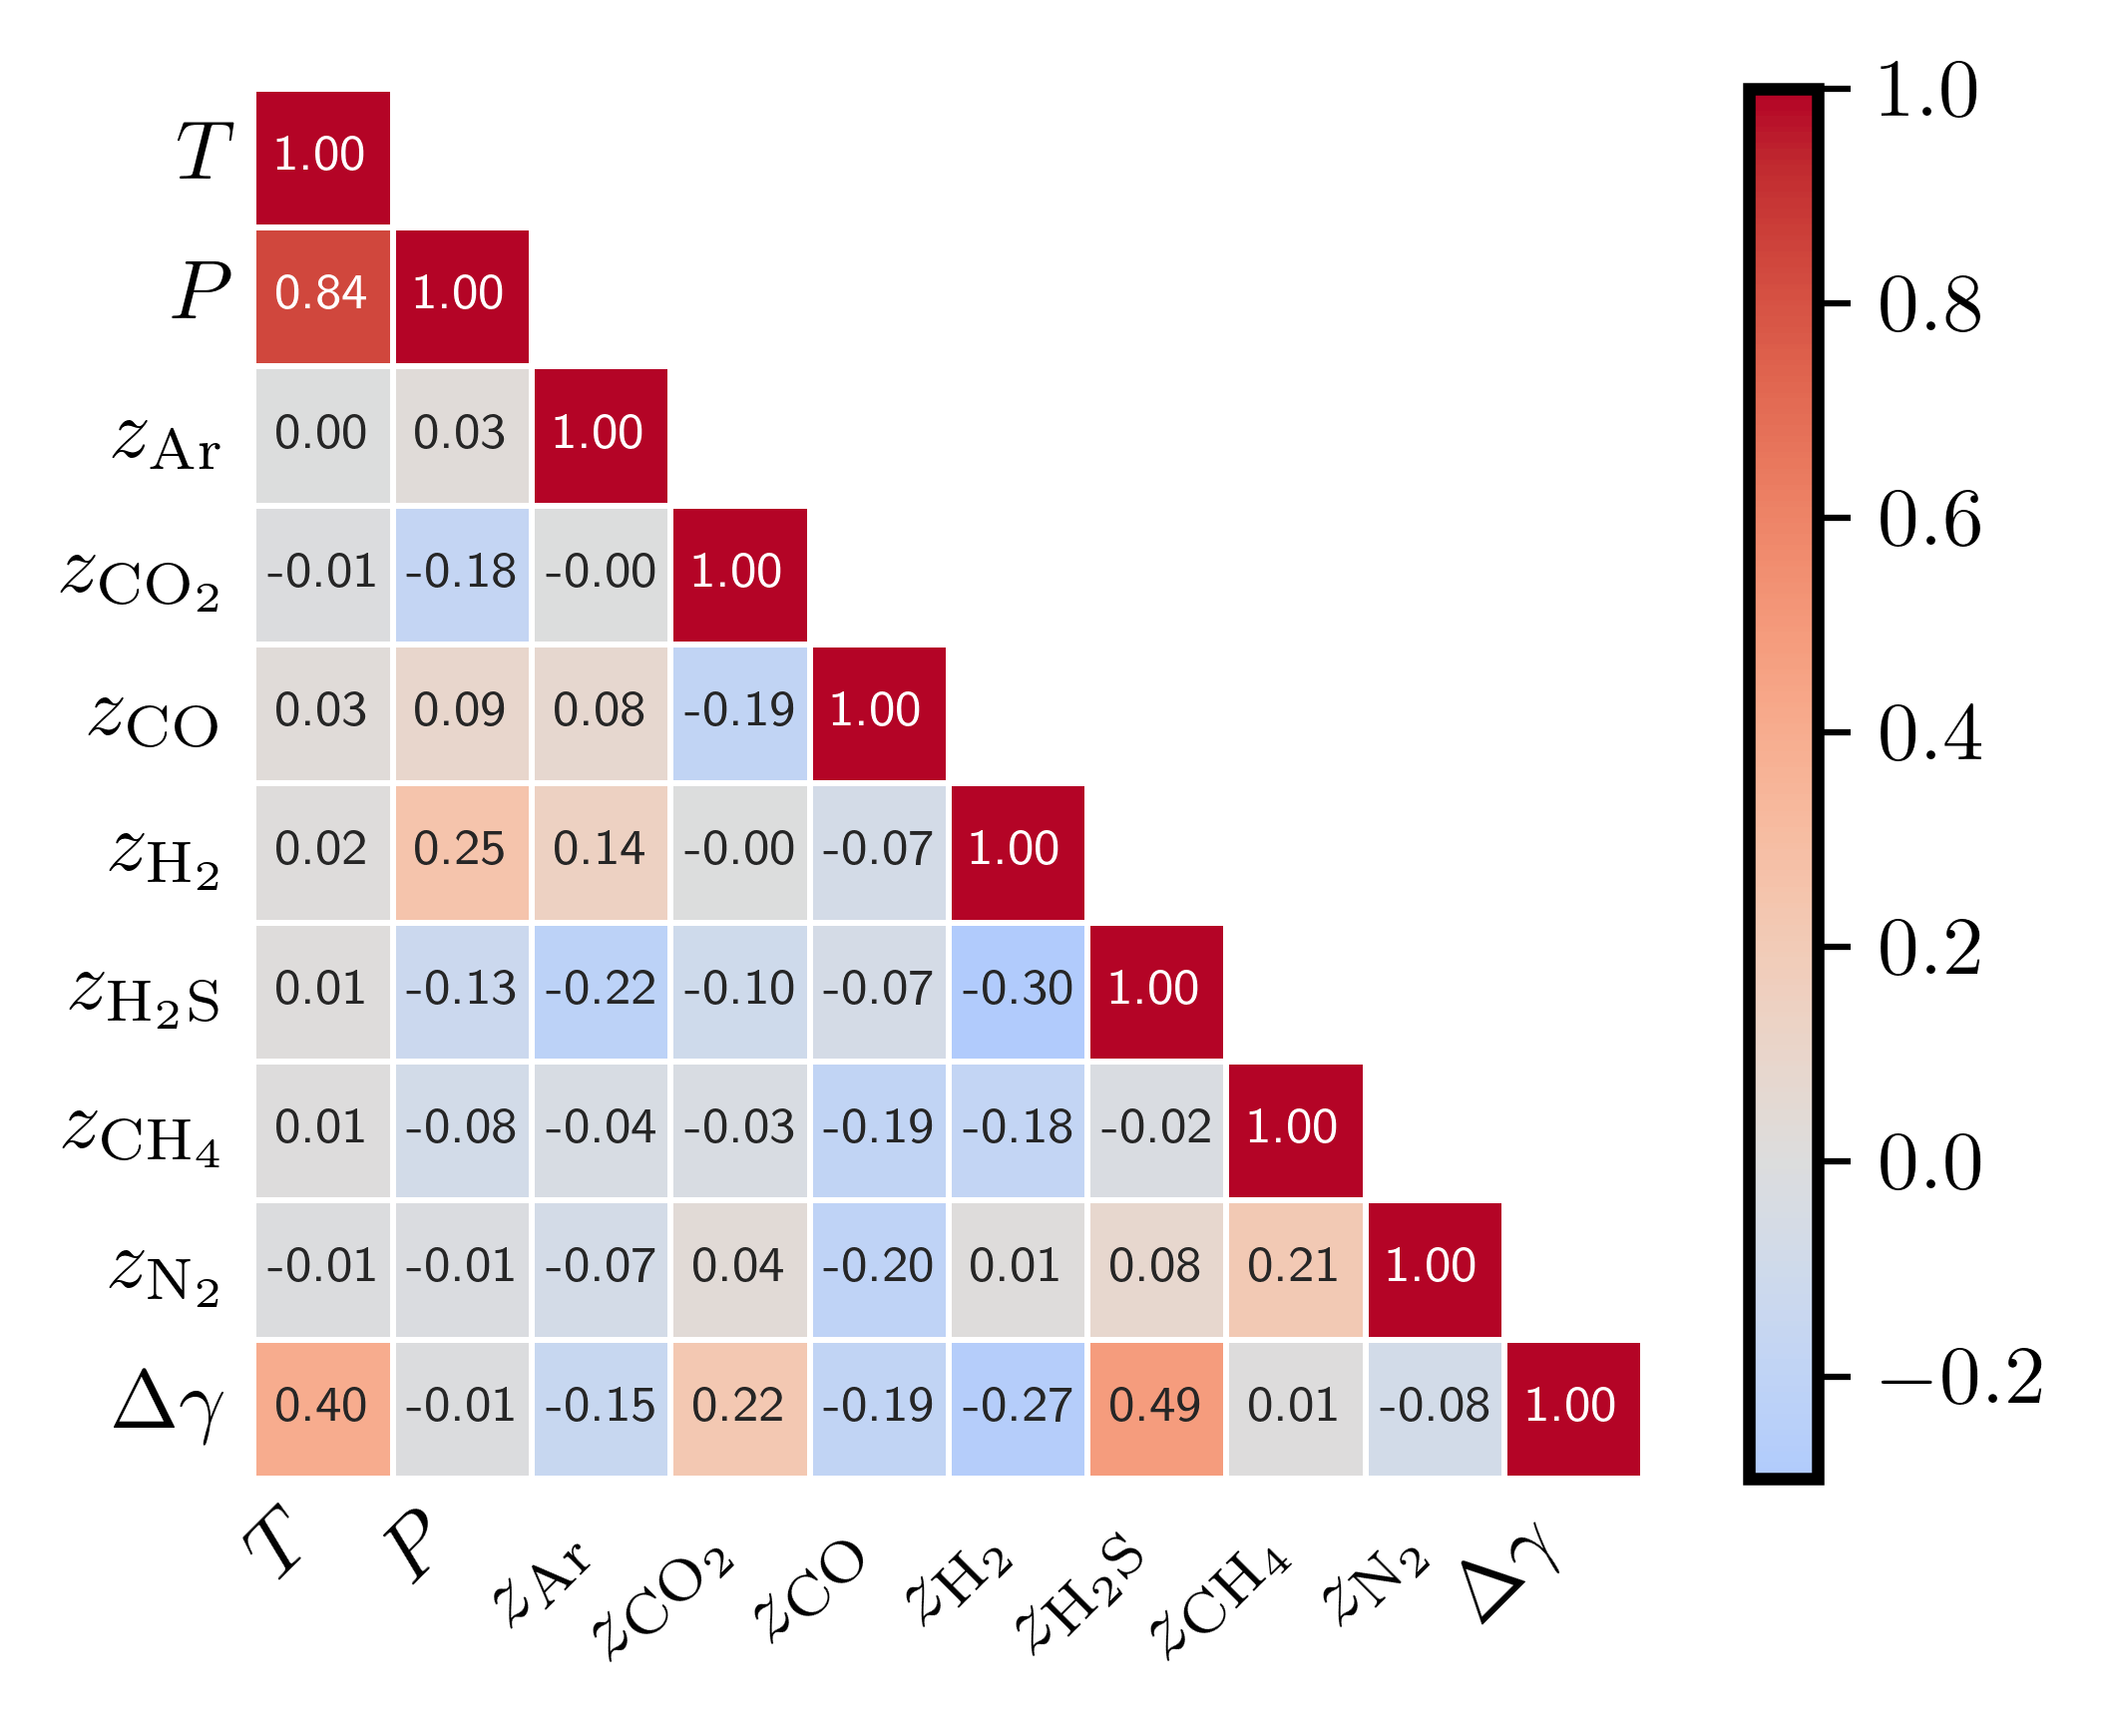

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [6]:
plot_correlation_heatmap(df, features, target, save_path="GPR_residual_correlation", folder=OUTPUT_FOLDER)

In [7]:
# prep = MLPreprocessing(df=df, features=features, target=target)

# fig_T, ax_T = prep.plot_scatter(
#     x="T",
#     y=target,
#     color_by="P",
# )
# ax_T.axhline(0.0, color="black", linestyle=":", linewidth=1.0)
# ps.save_plot(fig_T, "GPR_residual_vs_T", folder=OUTPUT_FOLDER)

# fig_P, ax_P = prep.plot_scatter(
#     x="P",
#     y=target,
#     color_by="T",
# )
# ax_P.axhline(0.0, color="black", linestyle=":", linewidth=1.0)
# ps.save_plot(fig_P, "GPR_residual_vs_P", folder=OUTPUT_FOLDER)


In [8]:
print(df[["gamma_cDFT", "gamma_base", "residual"]].isna().sum())
print("Any NaN in X:", X.isna().any().any())
print("Any NaN in y:", y.isna().any())

gamma_cDFT    0
gamma_base    0
residual      0
dtype: int64
Any NaN in X: False
Any NaN in y: False


In [9]:
# Kernel 
#Option1: const * RBF + WhiteKerneln_features = X_train.shape[1]
n_features = X_train.shape[1]
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3)) *
    RBF(length_scale=np.ones(n_features), length_scale_bounds=(1e-2, 1e3)) +
    WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e0))
)

# Pipeline
gpr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,
        normalize_y=True,
        n_restarts_optimizer=2,
        random_state=42
    ))
]) 

# Fit
gpr_model.fit(X_train, y_train)

# Predictions
y_train_pred, y_train_std = gpr_model.predict(X_train, return_std=True)
y_val_pred, y_val_std = gpr_model.predict(X_val, return_std=True)
y_test_pred, y_test_std = gpr_model.predict(X_test, return_std=True)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, unit="mN/m", y_val=y_val, y_val_pred=y_val_pred)

/home/darshan/A6/py_A6/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Model Performance for residual

Training Set:
  R²:   0.988034
  RMSE: 0.094873 mN/m
  MAE:  0.040799 mN/m

Test Set:
  R²:   0.980047
  RMSE: 0.109579 mN/m
  MAE:  0.046302 mN/m

Validation Set:
  R²:   0.909784
  RMSE: 0.286284 mN/m
  MAE:  0.064919 mN/m


In [10]:
# Initialize MLPostprocessing
# GPR ARD feature importance: inverse length scales from the RBF kernel
# Kernel structure: (ConstantKernel * RBF) + WhiteKernel -> k1.k2.length_scale
_length_scales = gpr_model.named_steps["gpr"].kernel_.k1.k2.length_scale
_feature_importances = 1.0 / _length_scales
_feature_importances = _feature_importances / _feature_importances.sum()  # normalize

post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="gamma",
    feature_importances=_feature_importances,
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

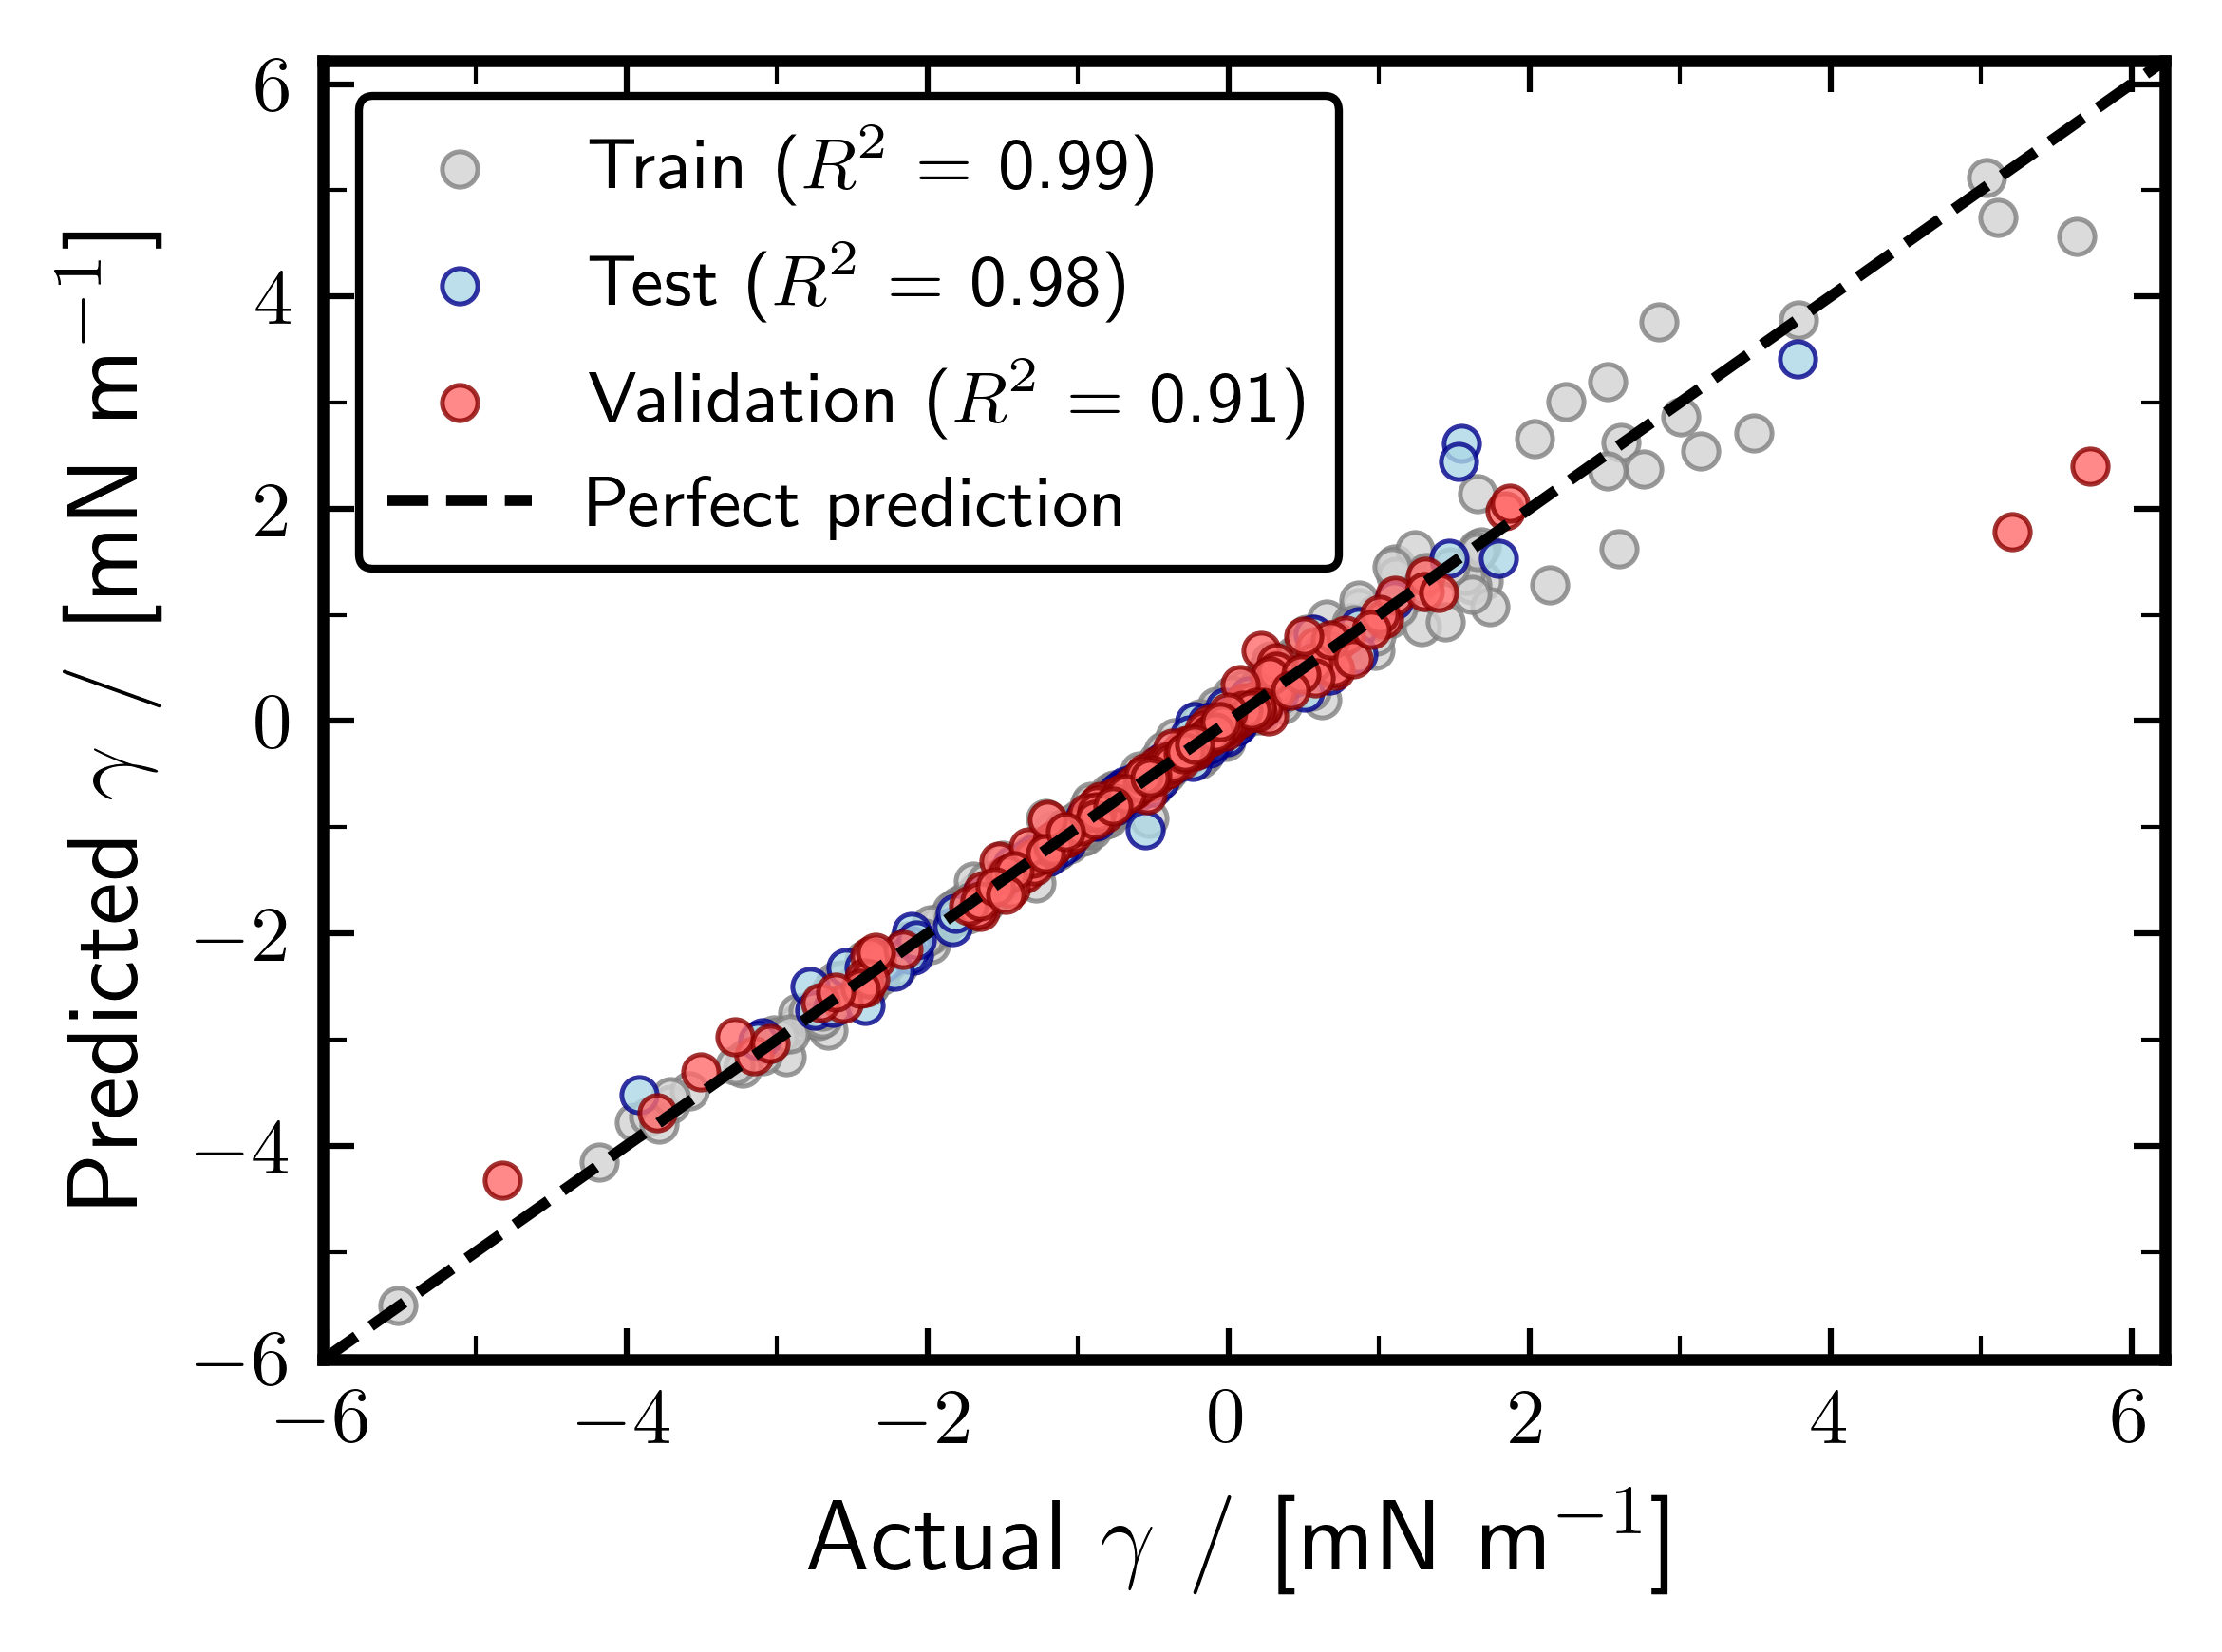

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $\\gamma$ / [mN m$^{-1}$]', ylabel='Predicted $\\gamma$ / [mN m$^{-1}$]'>)

In [11]:
# Parity plot
post.plot_parity(model_name="GPR (RBF)", save_path="GPR_gamma_parity_plot", folder=OUTPUT_FOLDER)

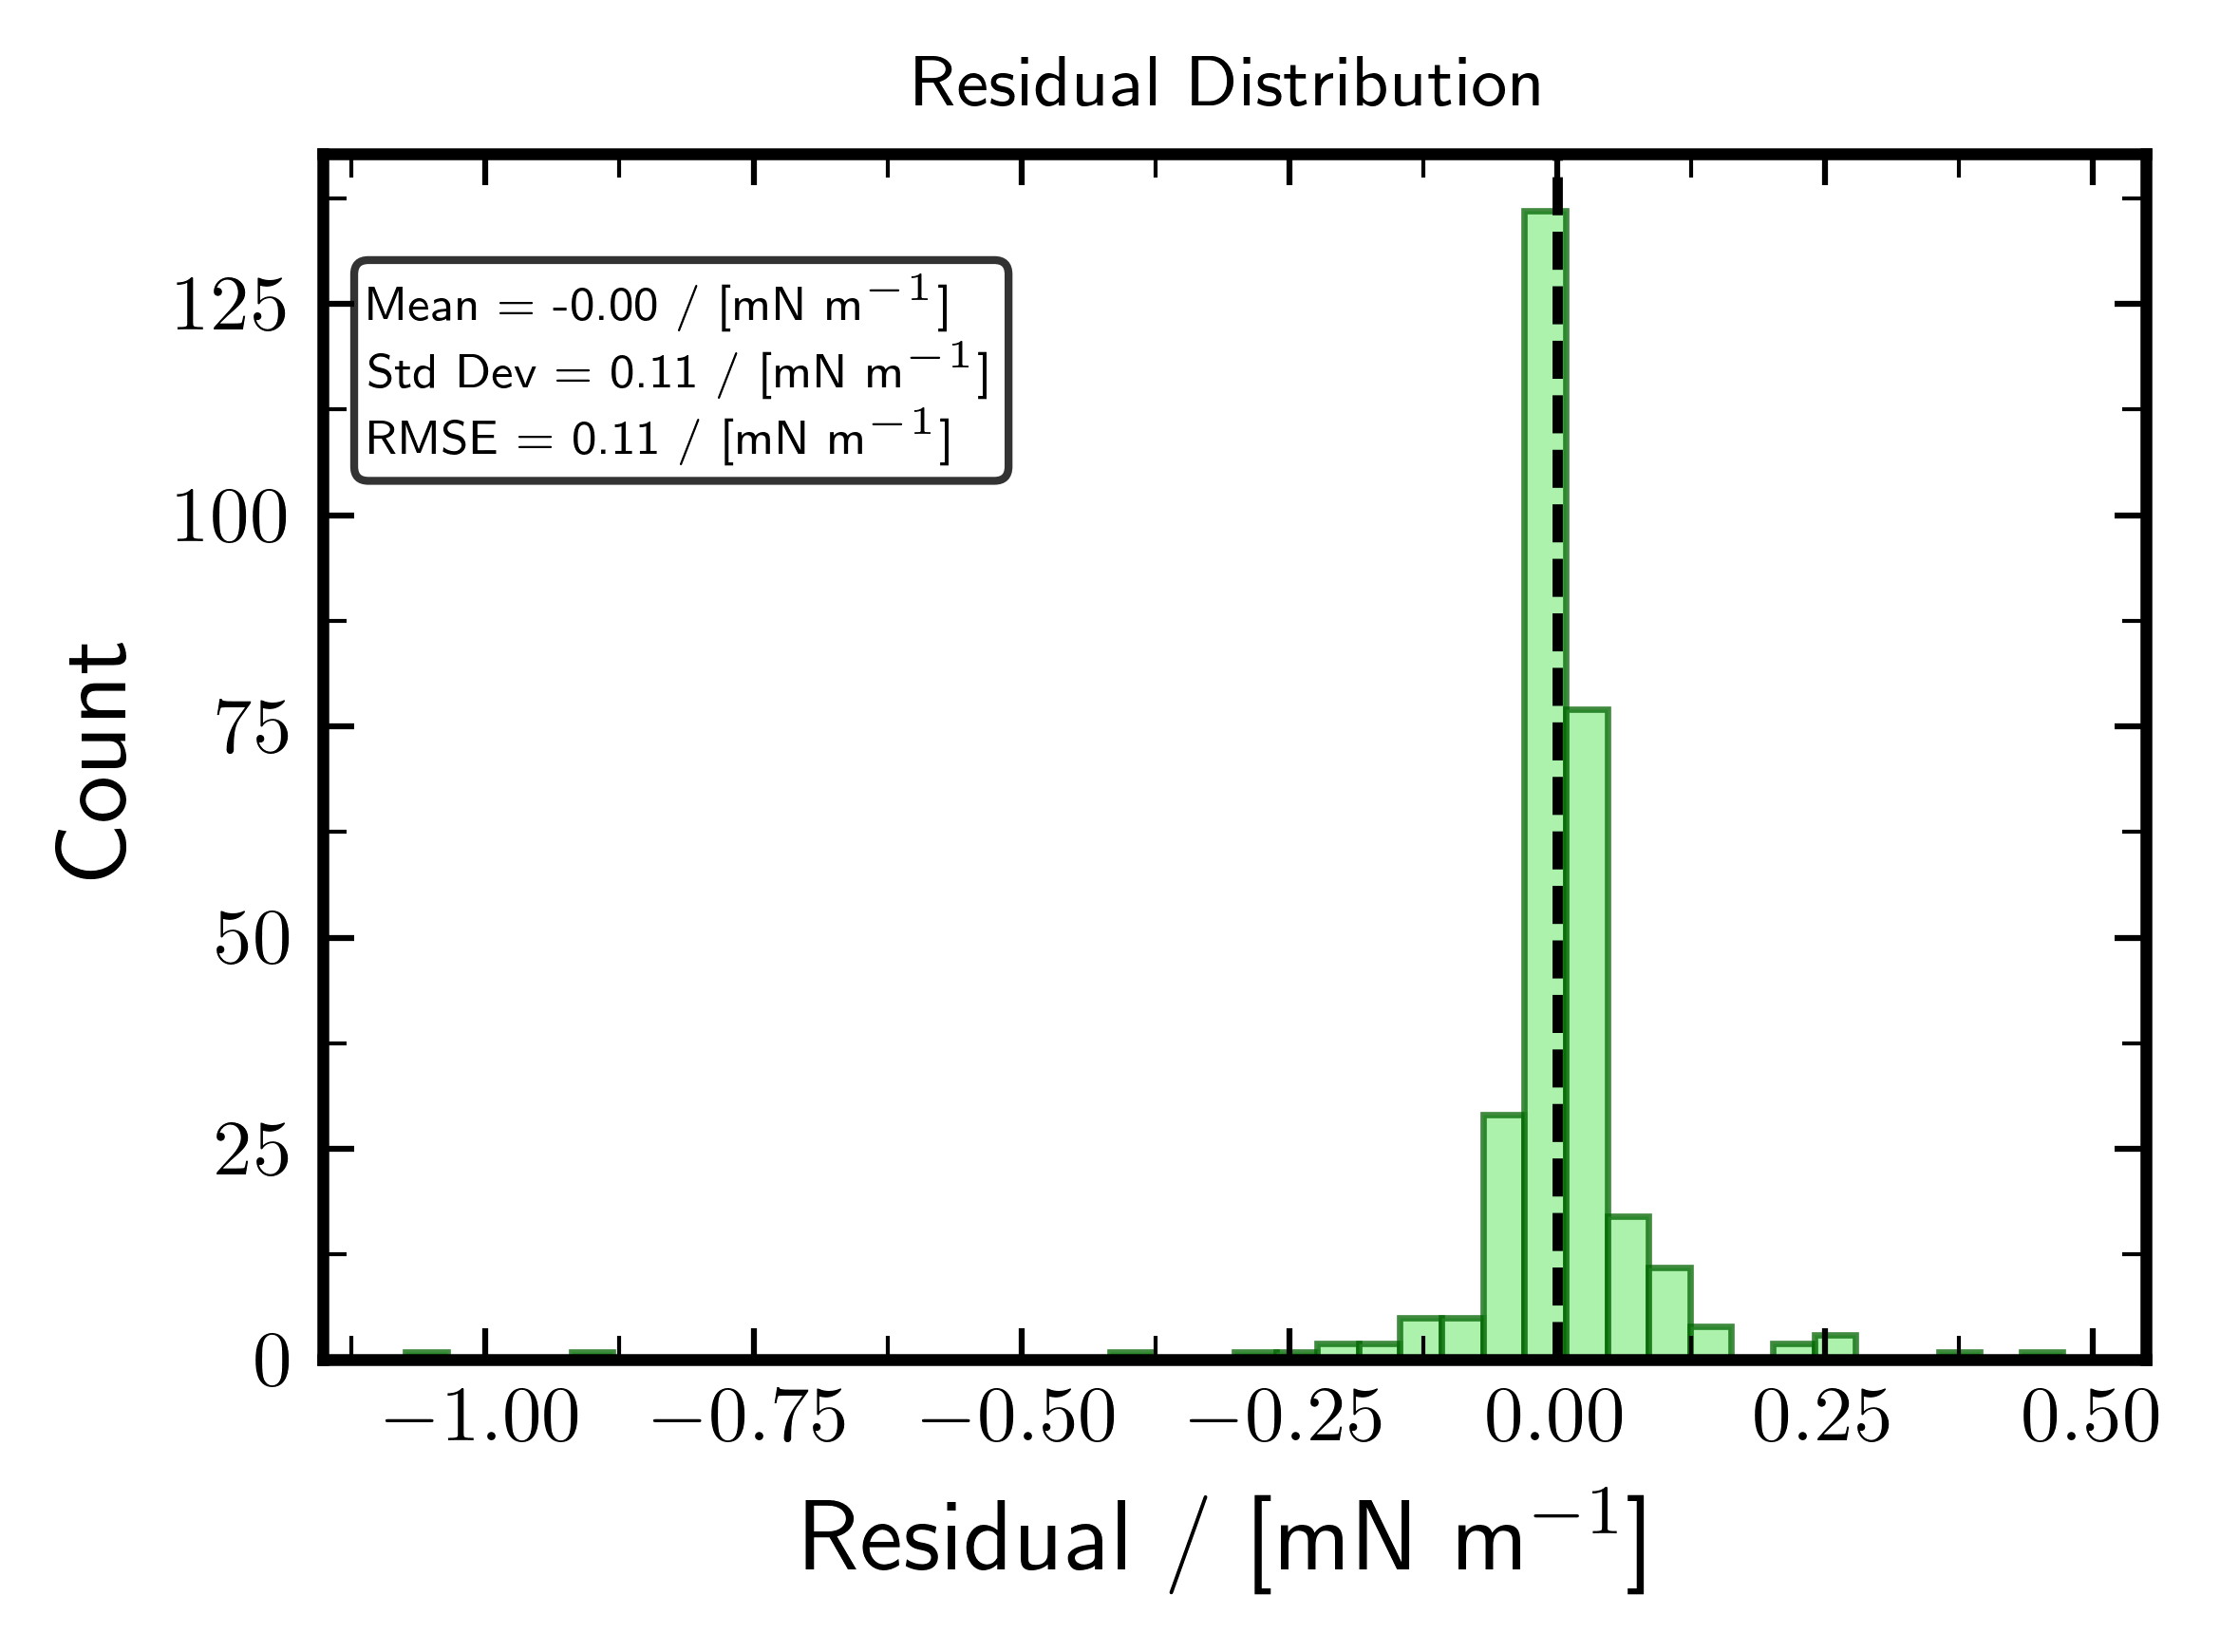

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Residual Distribution'}, xlabel='Residual / [mN m$^{-1}$]', ylabel='Count'>)

In [12]:
# Residual distribution
post.plot_residual_distribution(save_path="GPR_gamma_residual_distribution", folder=OUTPUT_FOLDER)

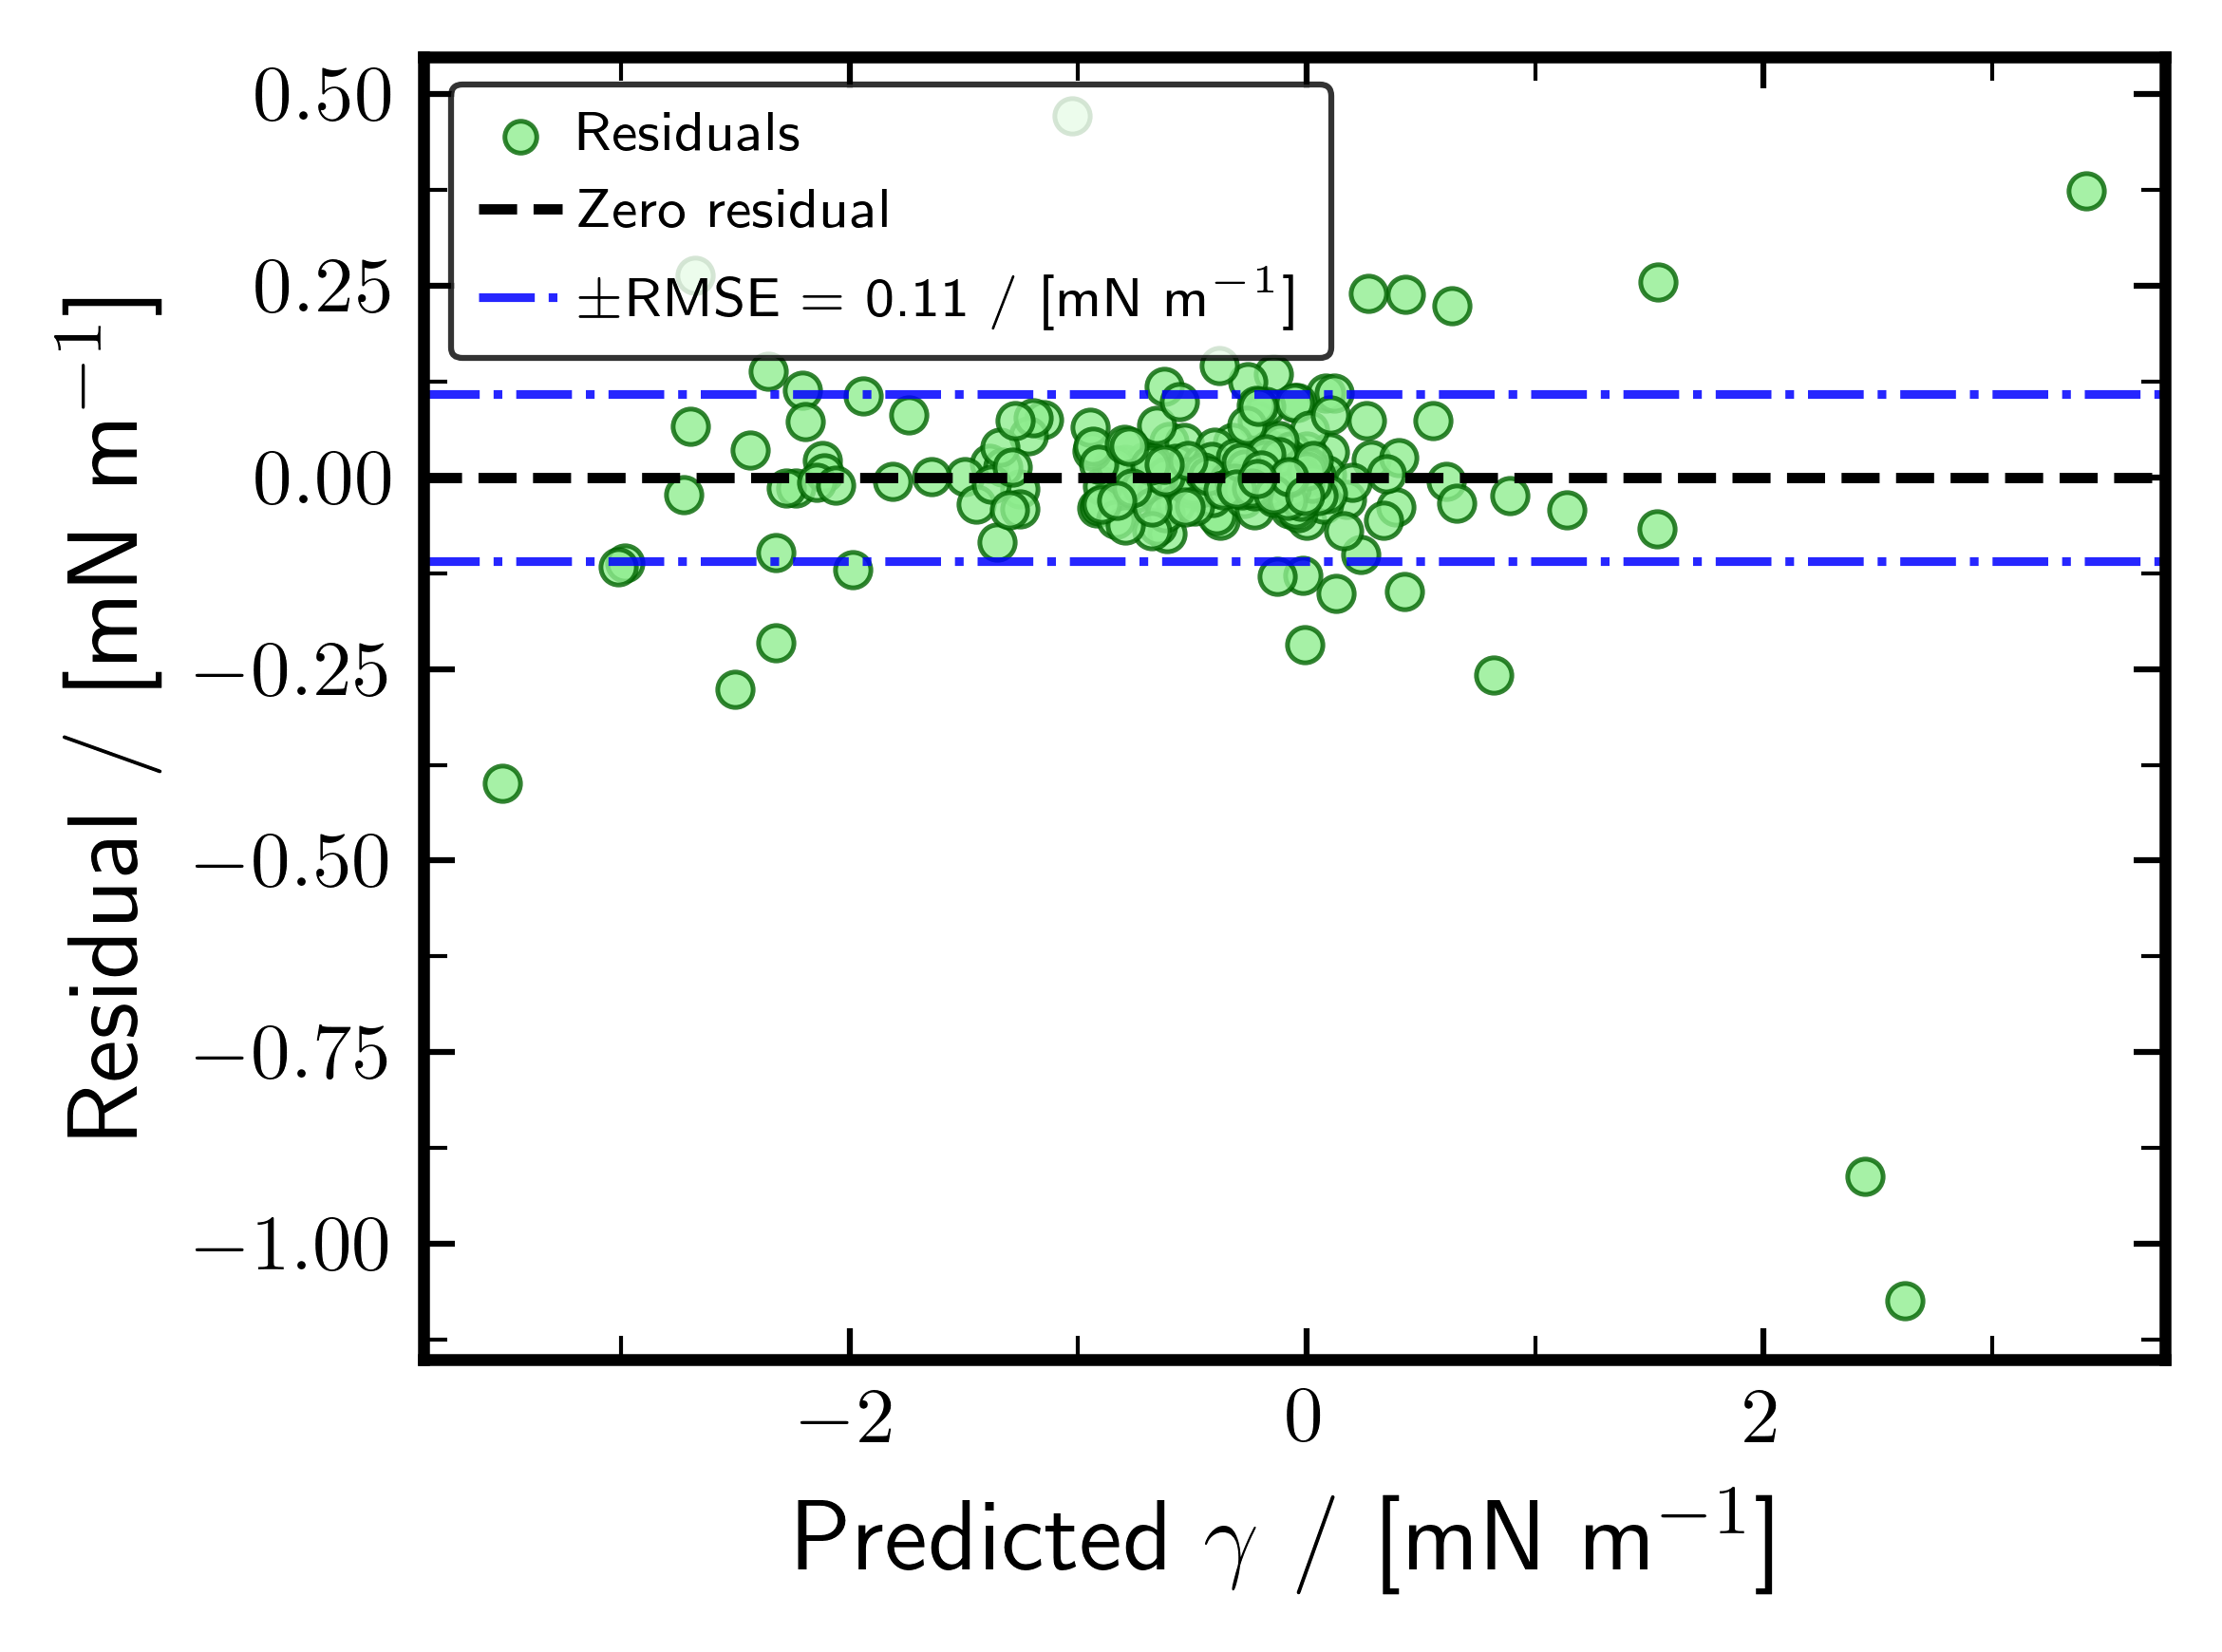

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $\\gamma$ / [mN m$^{-1}$]', ylabel='Residual / [mN m$^{-1}$]'>)

In [13]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="SVM_gamma_residual_vs_predicted", folder=OUTPUT_FOLDER)

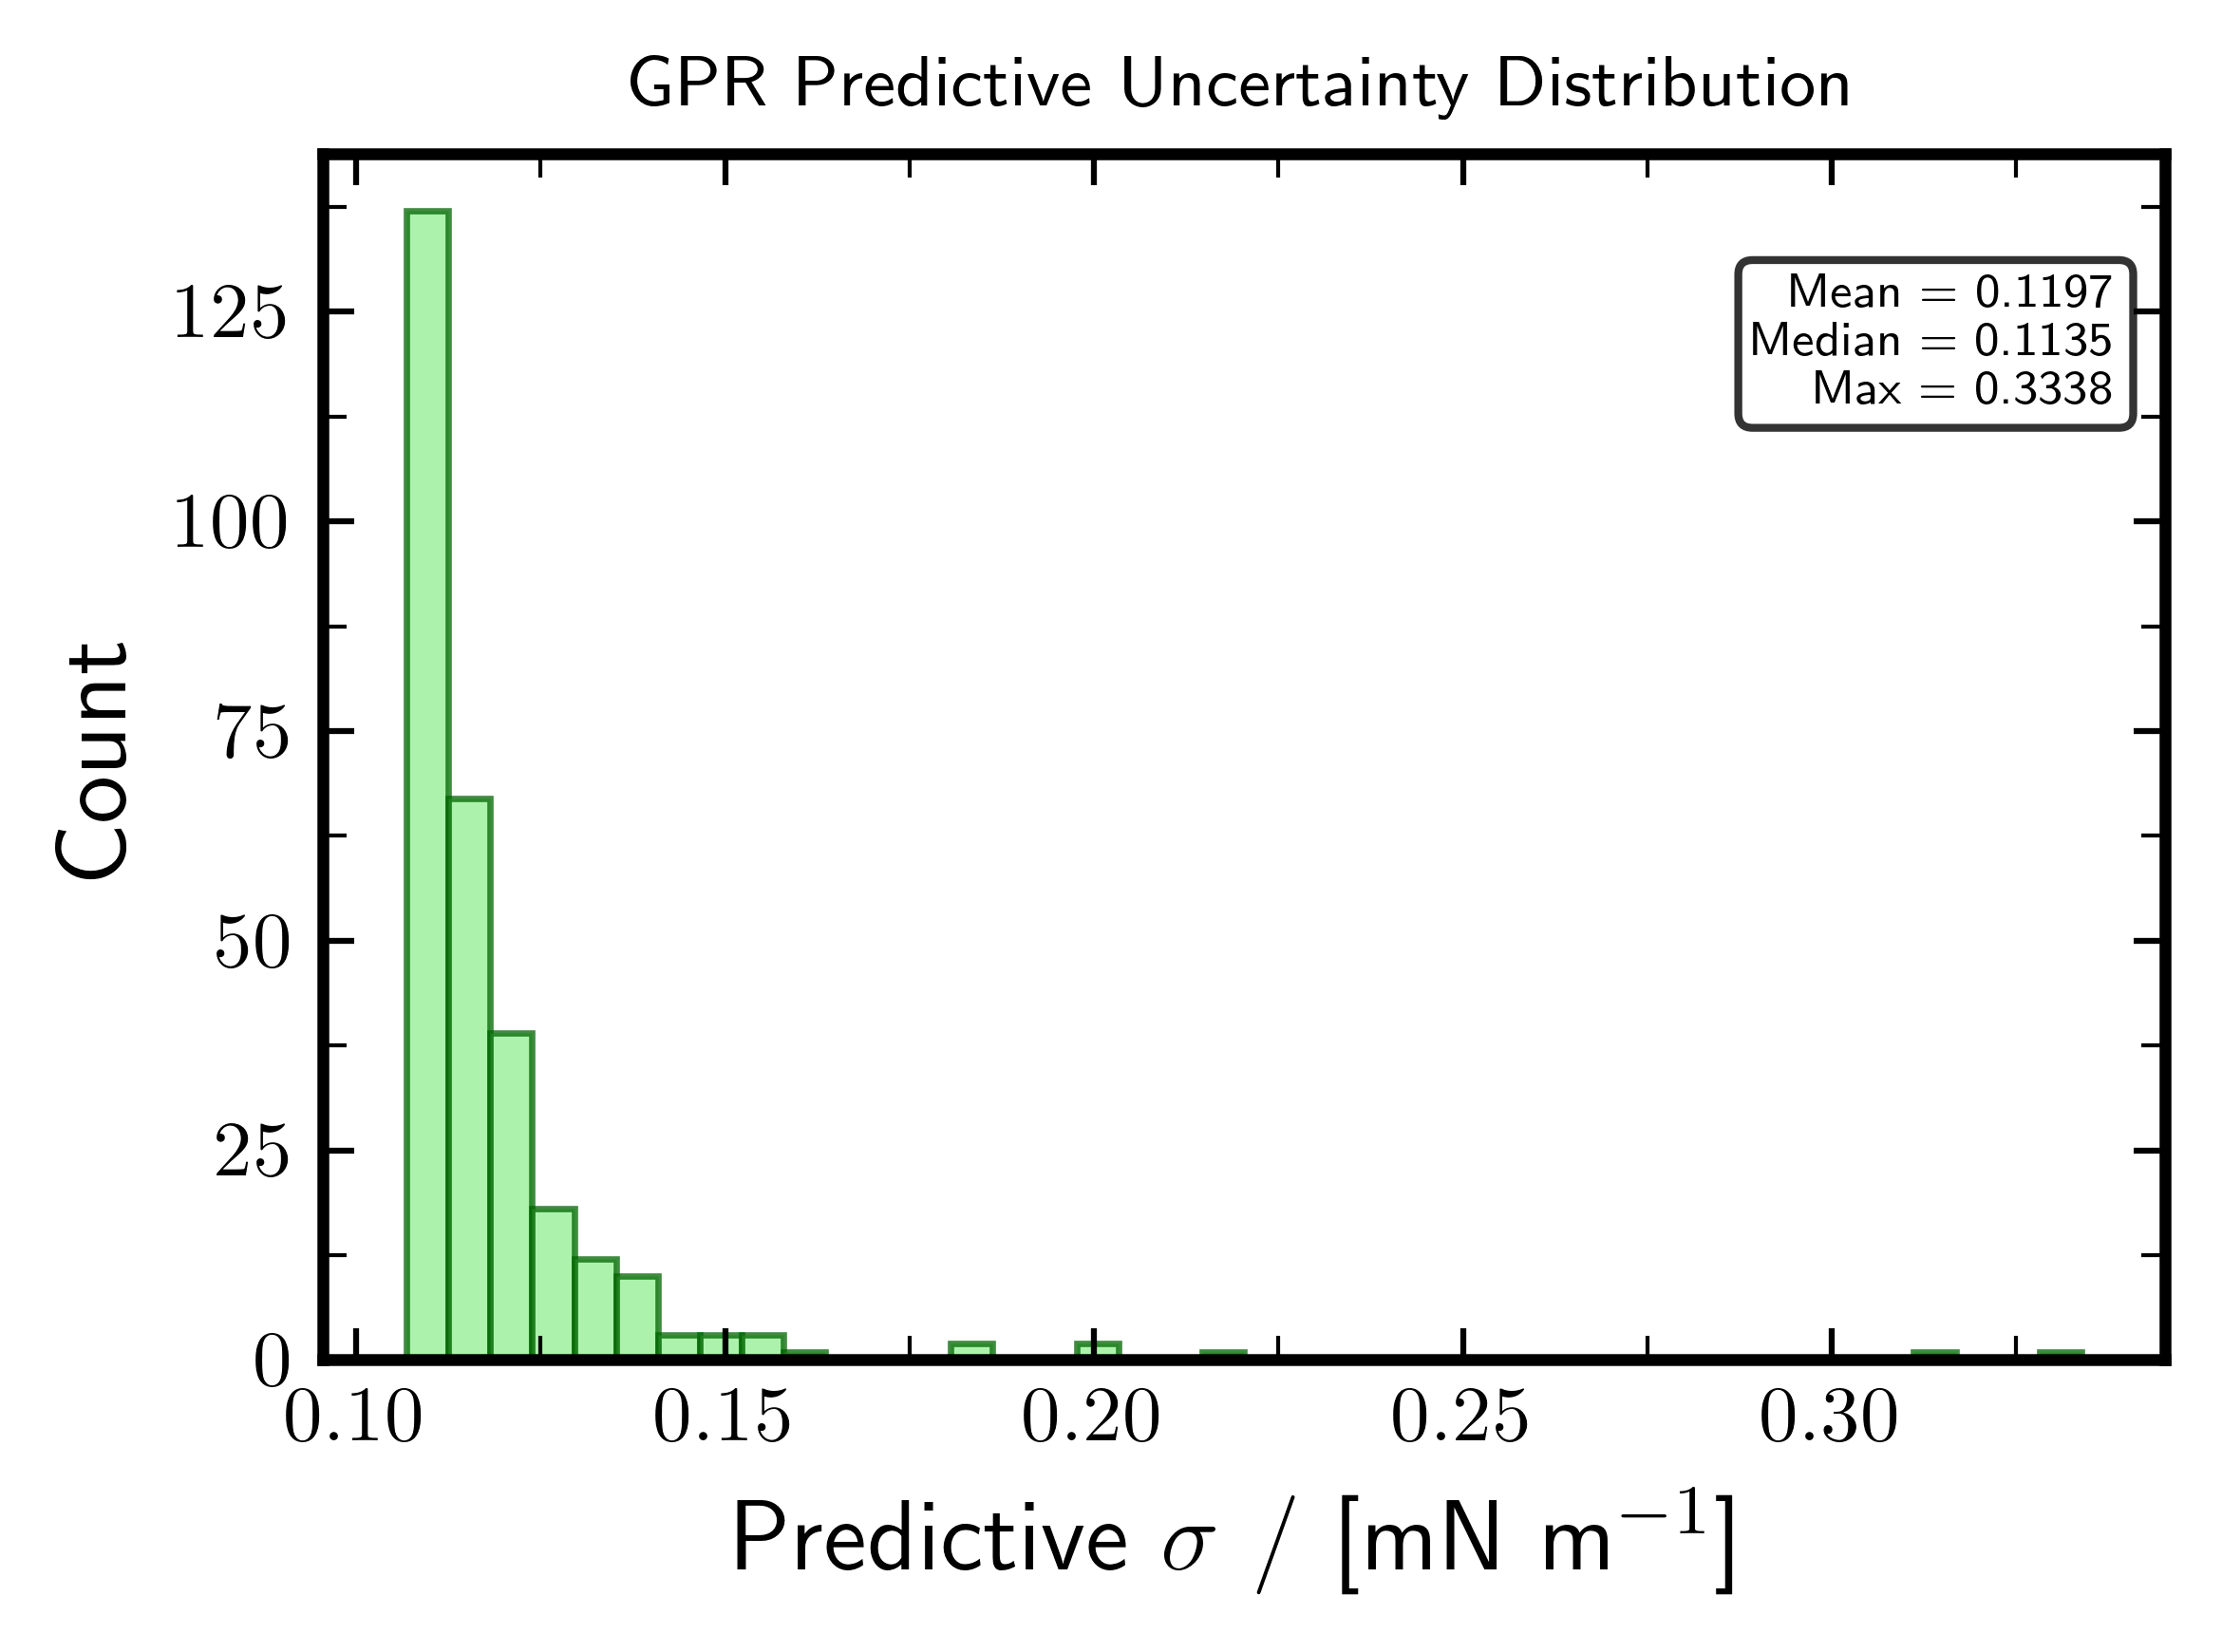

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'GPR Predictive Uncertainty Distribution'}, xlabel='Predictive $\\sigma$ / [mN m$^{-1}$]', ylabel='Count'>)

In [14]:
# GPR: Predictive std histogram
post.plot_std_histogram(y_test_std, save_path="GPR_gamma_std_histogram", folder=OUTPUT_FOLDER)

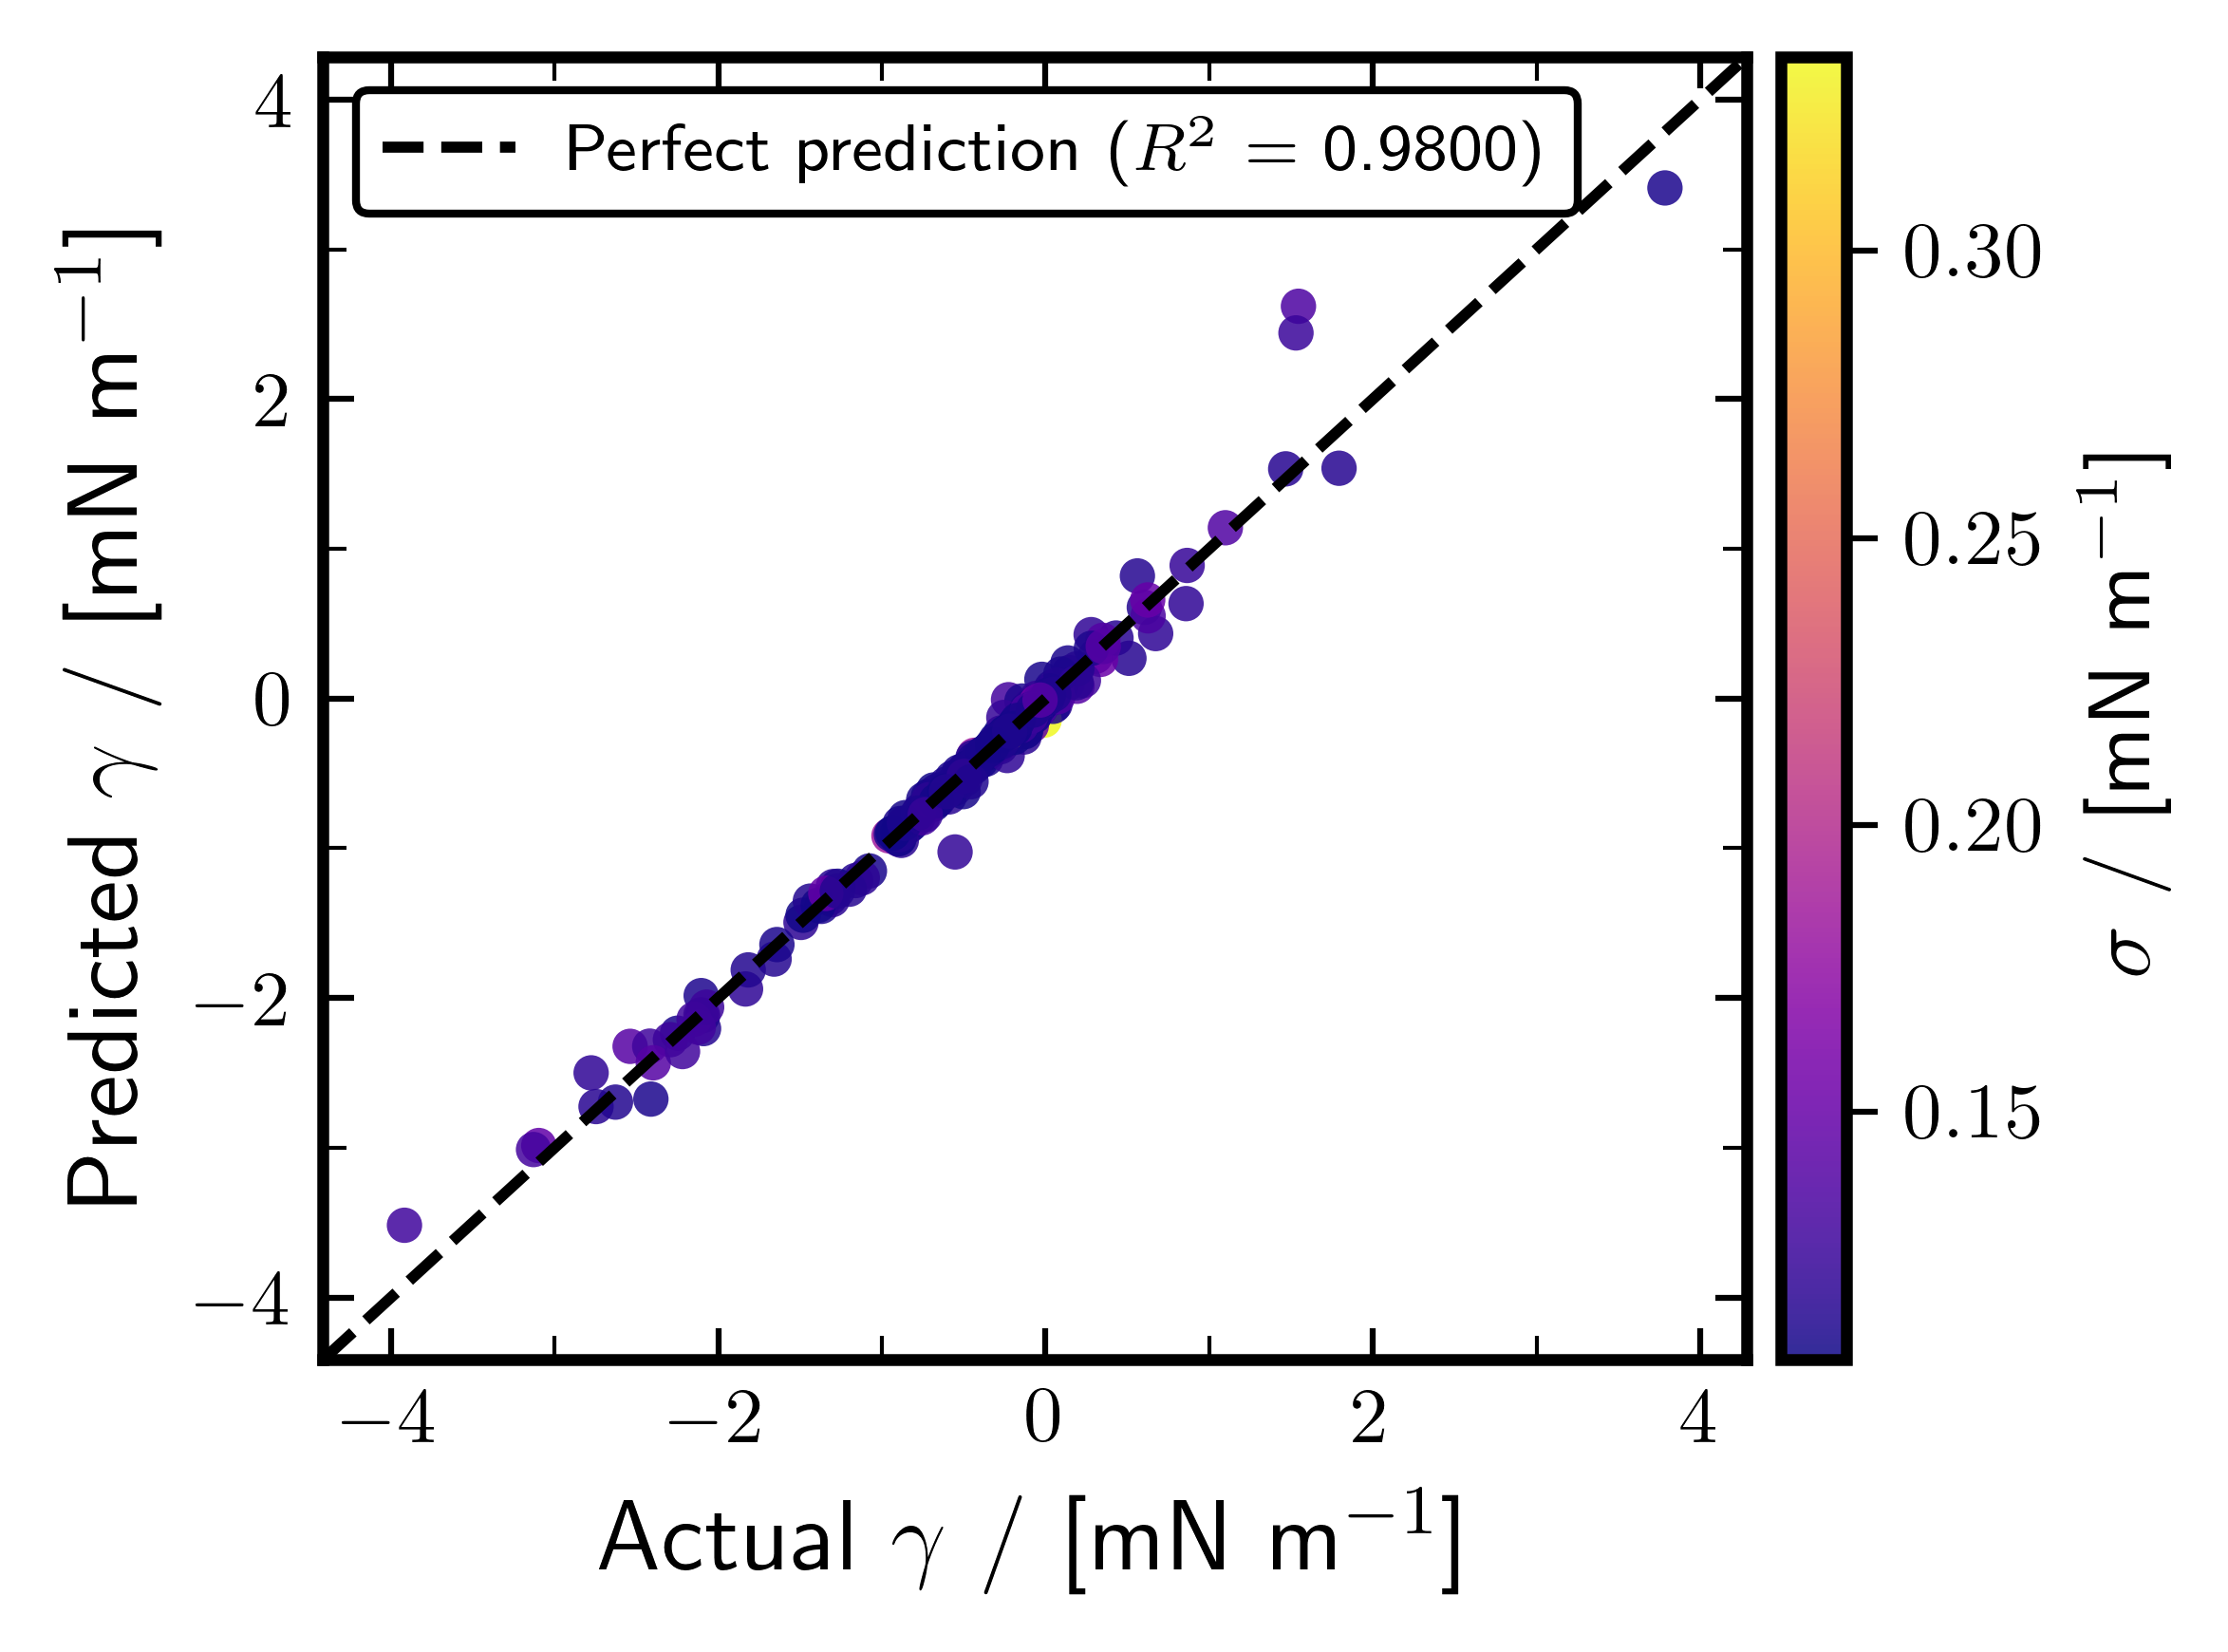

(<Figure size 2400x1800 with 2 Axes>,
 <Axes: xlabel='Actual $\\gamma$ / [mN m$^{-1}$]', ylabel='Predicted $\\gamma$ / [mN m$^{-1}$]'>)

In [15]:
# GPR: Parity plot colored by predictive std
post.plot_parity_colored_by_std(y_test_std, save_path="GPR_gamma_parity_colored_std", folder=OUTPUT_FOLDER)

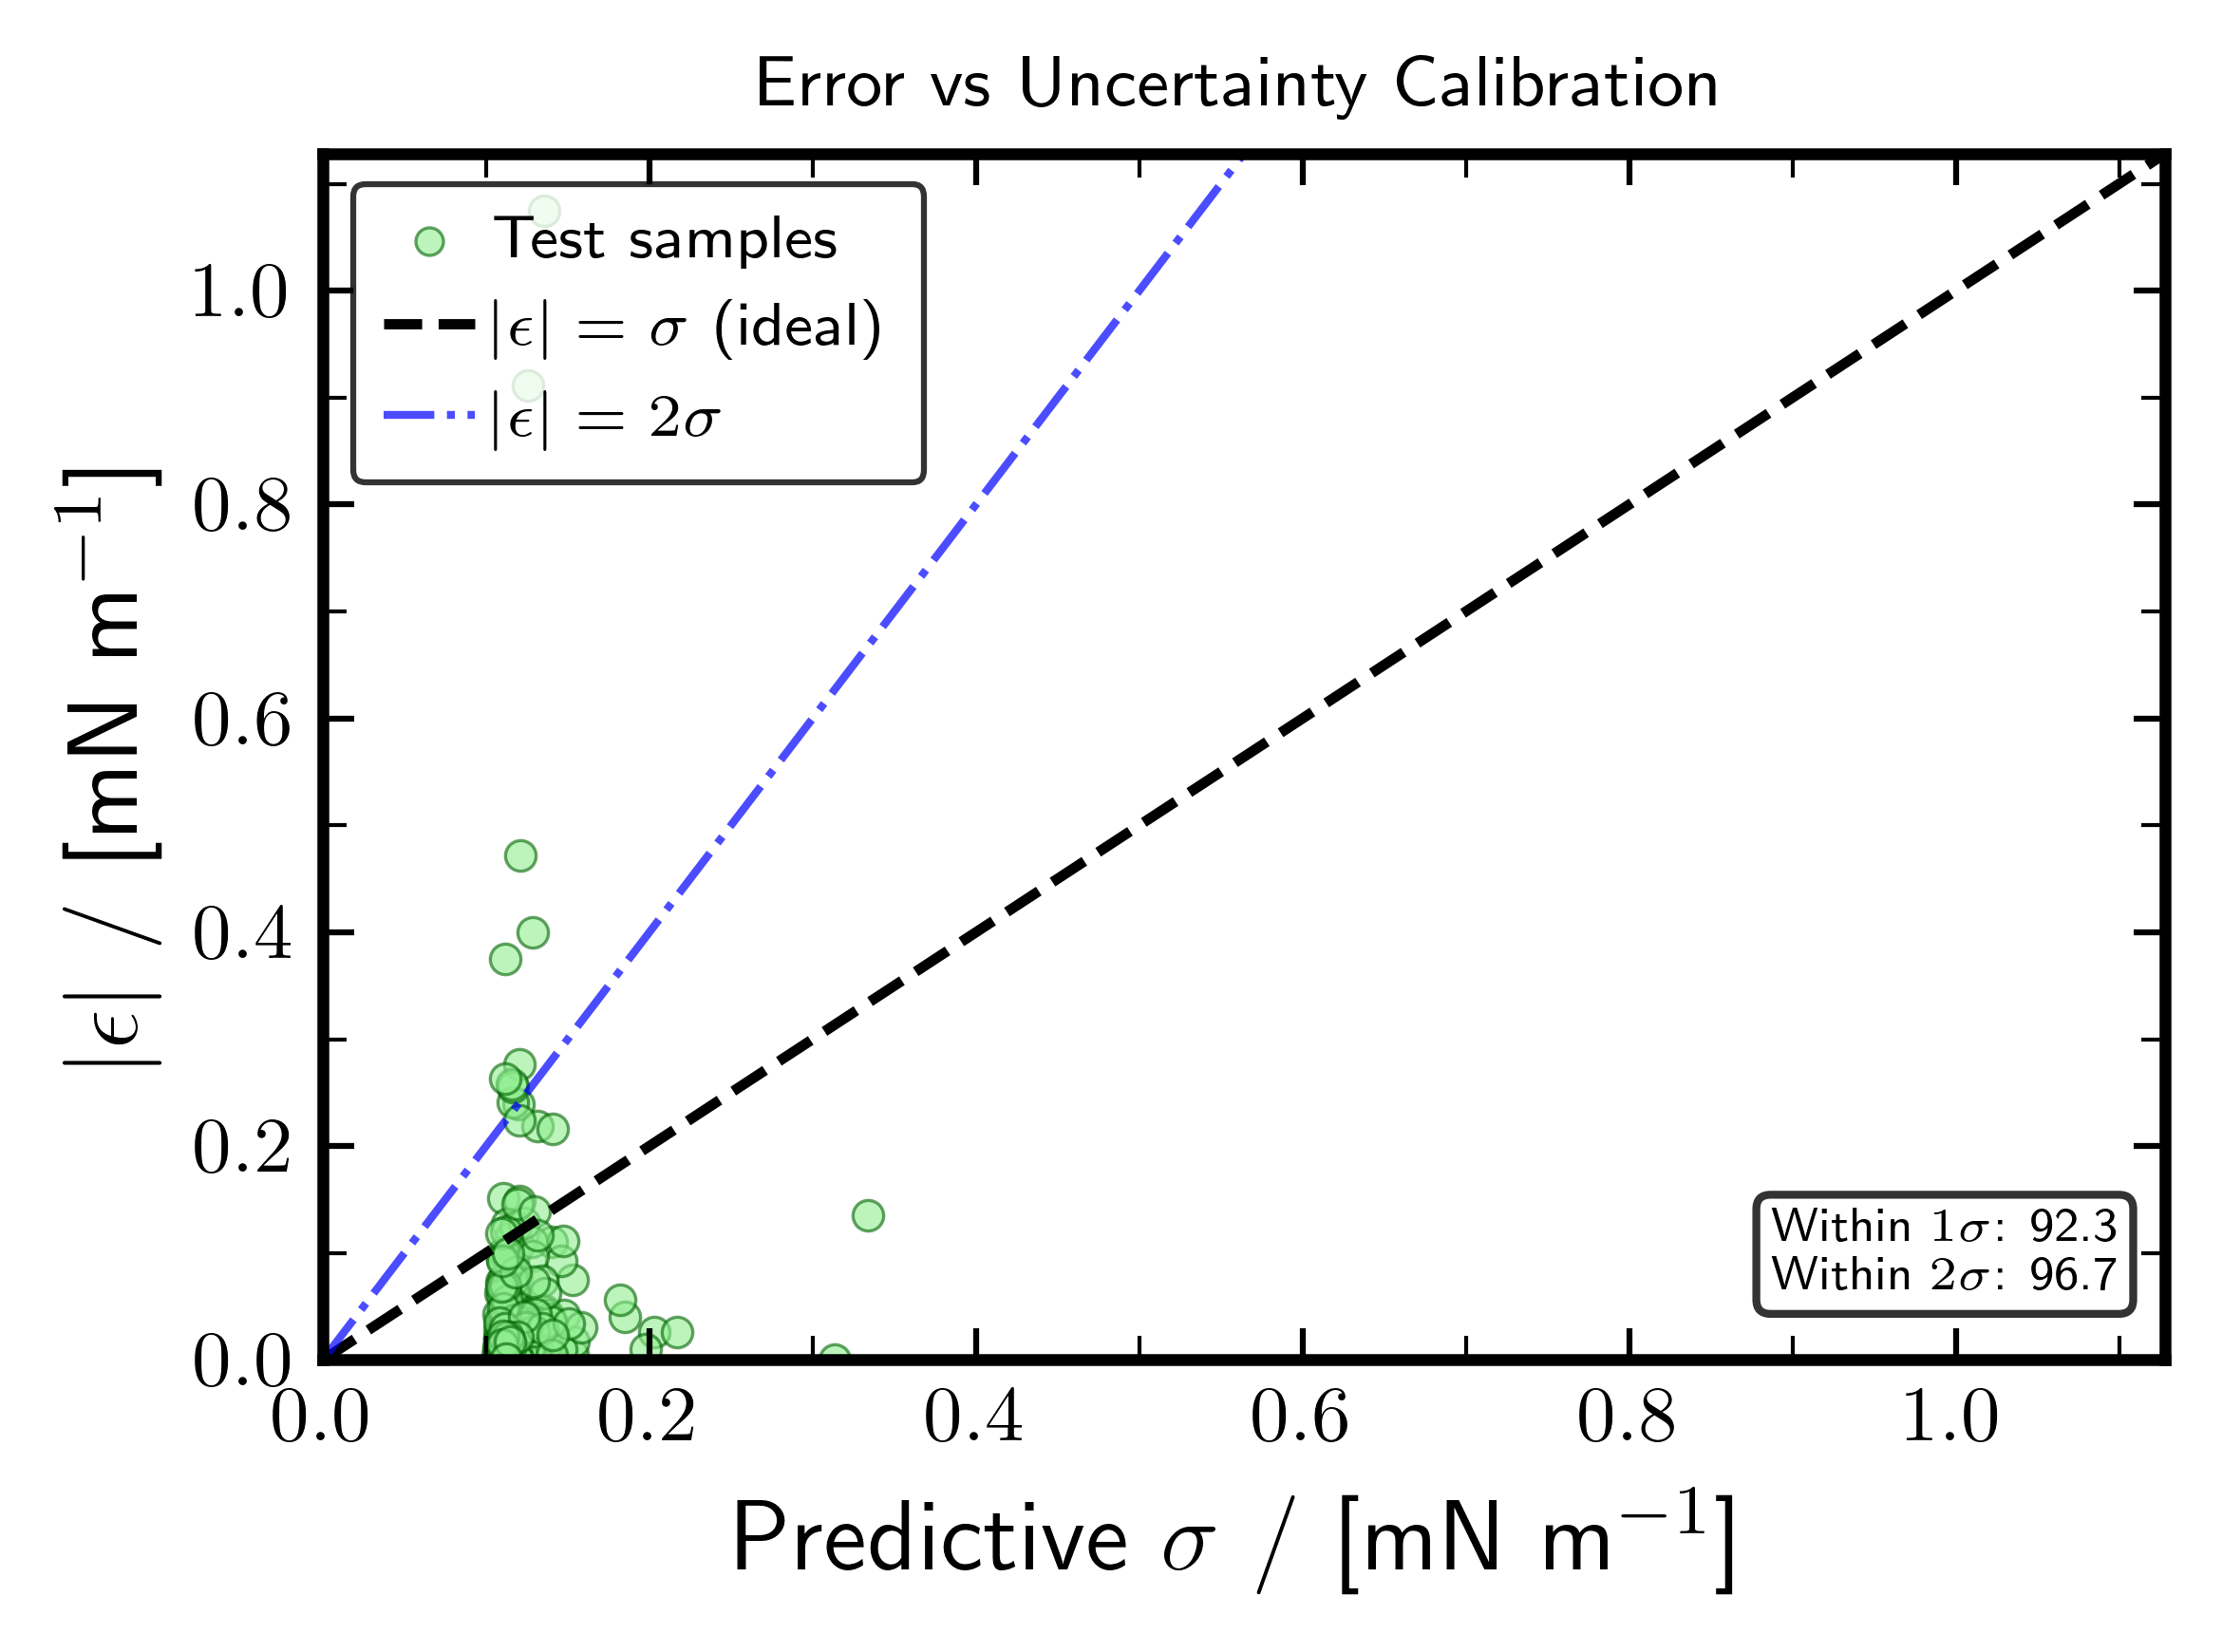

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: title={'center': 'Error vs Uncertainty Calibration'}, xlabel='Predictive $\\sigma$ / [mN m$^{-1}$]', ylabel='$|\\epsilon|$ / [mN m$^{-1}$]'>)

In [16]:
# GPR: |error| vs predictive std (calibration)
post.plot_error_vs_std(y_test_std, save_path="GPR_gamma_error_vs_std", folder=OUTPUT_FOLDER)

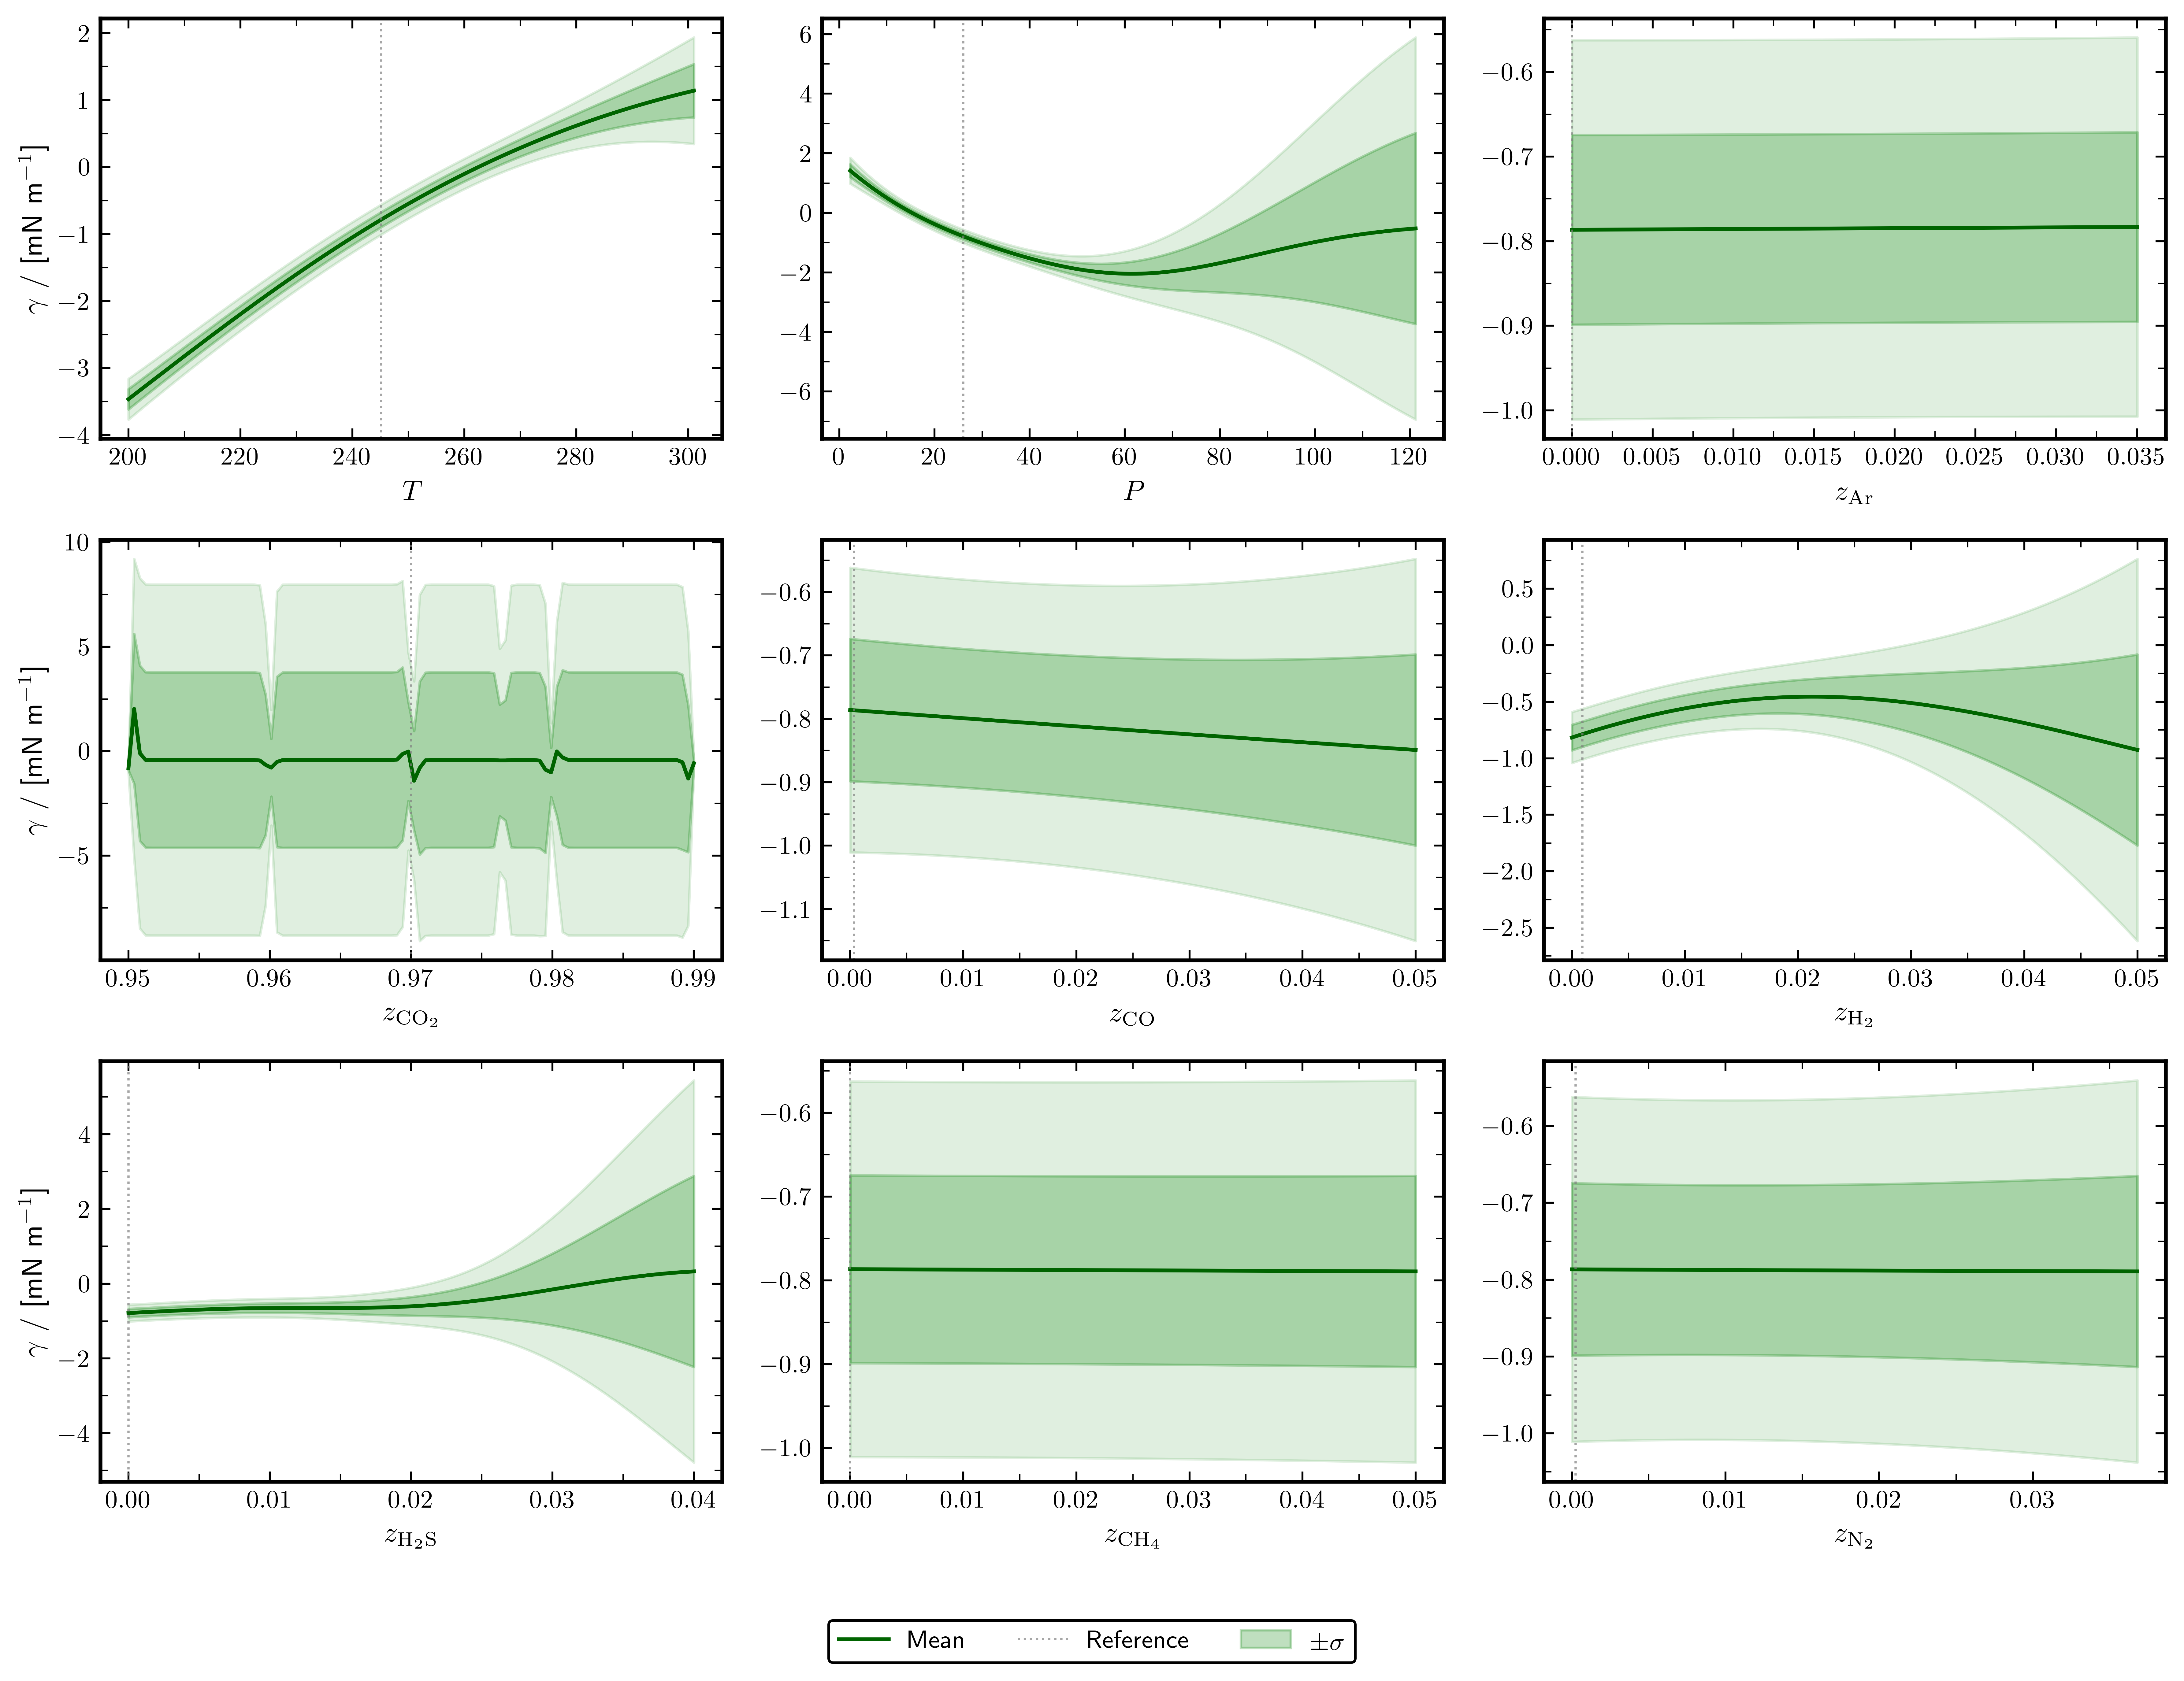

(<Figure size 7200x5400 with 9 Axes>,
 array([<Axes: xlabel='$T$', ylabel='$\\gamma$ / [mN m$^{-1}$]'>,
        <Axes: xlabel='$P$'>, <Axes: xlabel='$z_{\\mathrm{Ar}}$'>,
        <Axes: xlabel='$z_{\\mathrm{CO_2}}$', ylabel='$\\gamma$ / [mN m$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{CO}}$'>,
        <Axes: xlabel='$z_{\\mathrm{H_2}}$'>,
        <Axes: xlabel='$z_{\\mathrm{H_2S}}$', ylabel='$\\gamma$ / [mN m$^{-1}$]'>,
        <Axes: xlabel='$z_{\\mathrm{CH_4}}$'>,
        <Axes: xlabel='$z_{\\mathrm{N_2}}$'>], dtype=object))

In [17]:
# GPR: Response curves — saved individually per feature
X_ref = X_train.median().values
post.plot_response_curves(
    model=gpr_model,
    X_ref=X_ref,
    feature_names=features,
    X_train=X_train,
    n_points=100,
    return_std=True,
    save_individually=True,
    save_path="GPR_gamma_response",
    folder=OUTPUT_FOLDER,
)

In [18]:
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
model_path = os.path.join(OUTPUT_FOLDER, "GPR_residual_model.joblib")
joblib.dump(gpr_model, model_path)
print(f"Model saved to: {model_path}")

Model saved to: GPR_RESIDUAL_OUTPUTS/GPR_residual_model.joblib


In [19]:
# Reconstruct full gamma_cDFT = gamma_base + residual_pred
from sklearn.metrics import r2_score as _r2

gamma_base_train = df.loc[X_train.index, "gamma_base"].values
gamma_base_test  = df.loc[X_test.index,  "gamma_base"].values
gamma_base_val   = df.loc[X_val.index,   "gamma_base"].values

gamma_cDFT_train = df.loc[X_train.index, "gamma_cDFT"].values
gamma_cDFT_test  = df.loc[X_test.index,  "gamma_cDFT"].values
gamma_cDFT_val   = df.loc[X_val.index,   "gamma_cDFT"].values

gamma_pred_train = gamma_base_train + y_train_pred
gamma_pred_test  = gamma_base_test  + y_test_pred
gamma_pred_val   = gamma_base_val   + y_val_pred

# std carries through the additive reconstruction unchanged
print(f"Reconstructed gamma_cDFT  R² — train: {_r2(gamma_cDFT_train, gamma_pred_train):.4f} "
      f"| test: {_r2(gamma_cDFT_test, gamma_pred_test):.4f} "
      f"| val:  {_r2(gamma_cDFT_val,  gamma_pred_val):.4f}")

Reconstructed gamma_cDFT  R² — train: 0.9997 | test: 0.9995 | val:  0.9967


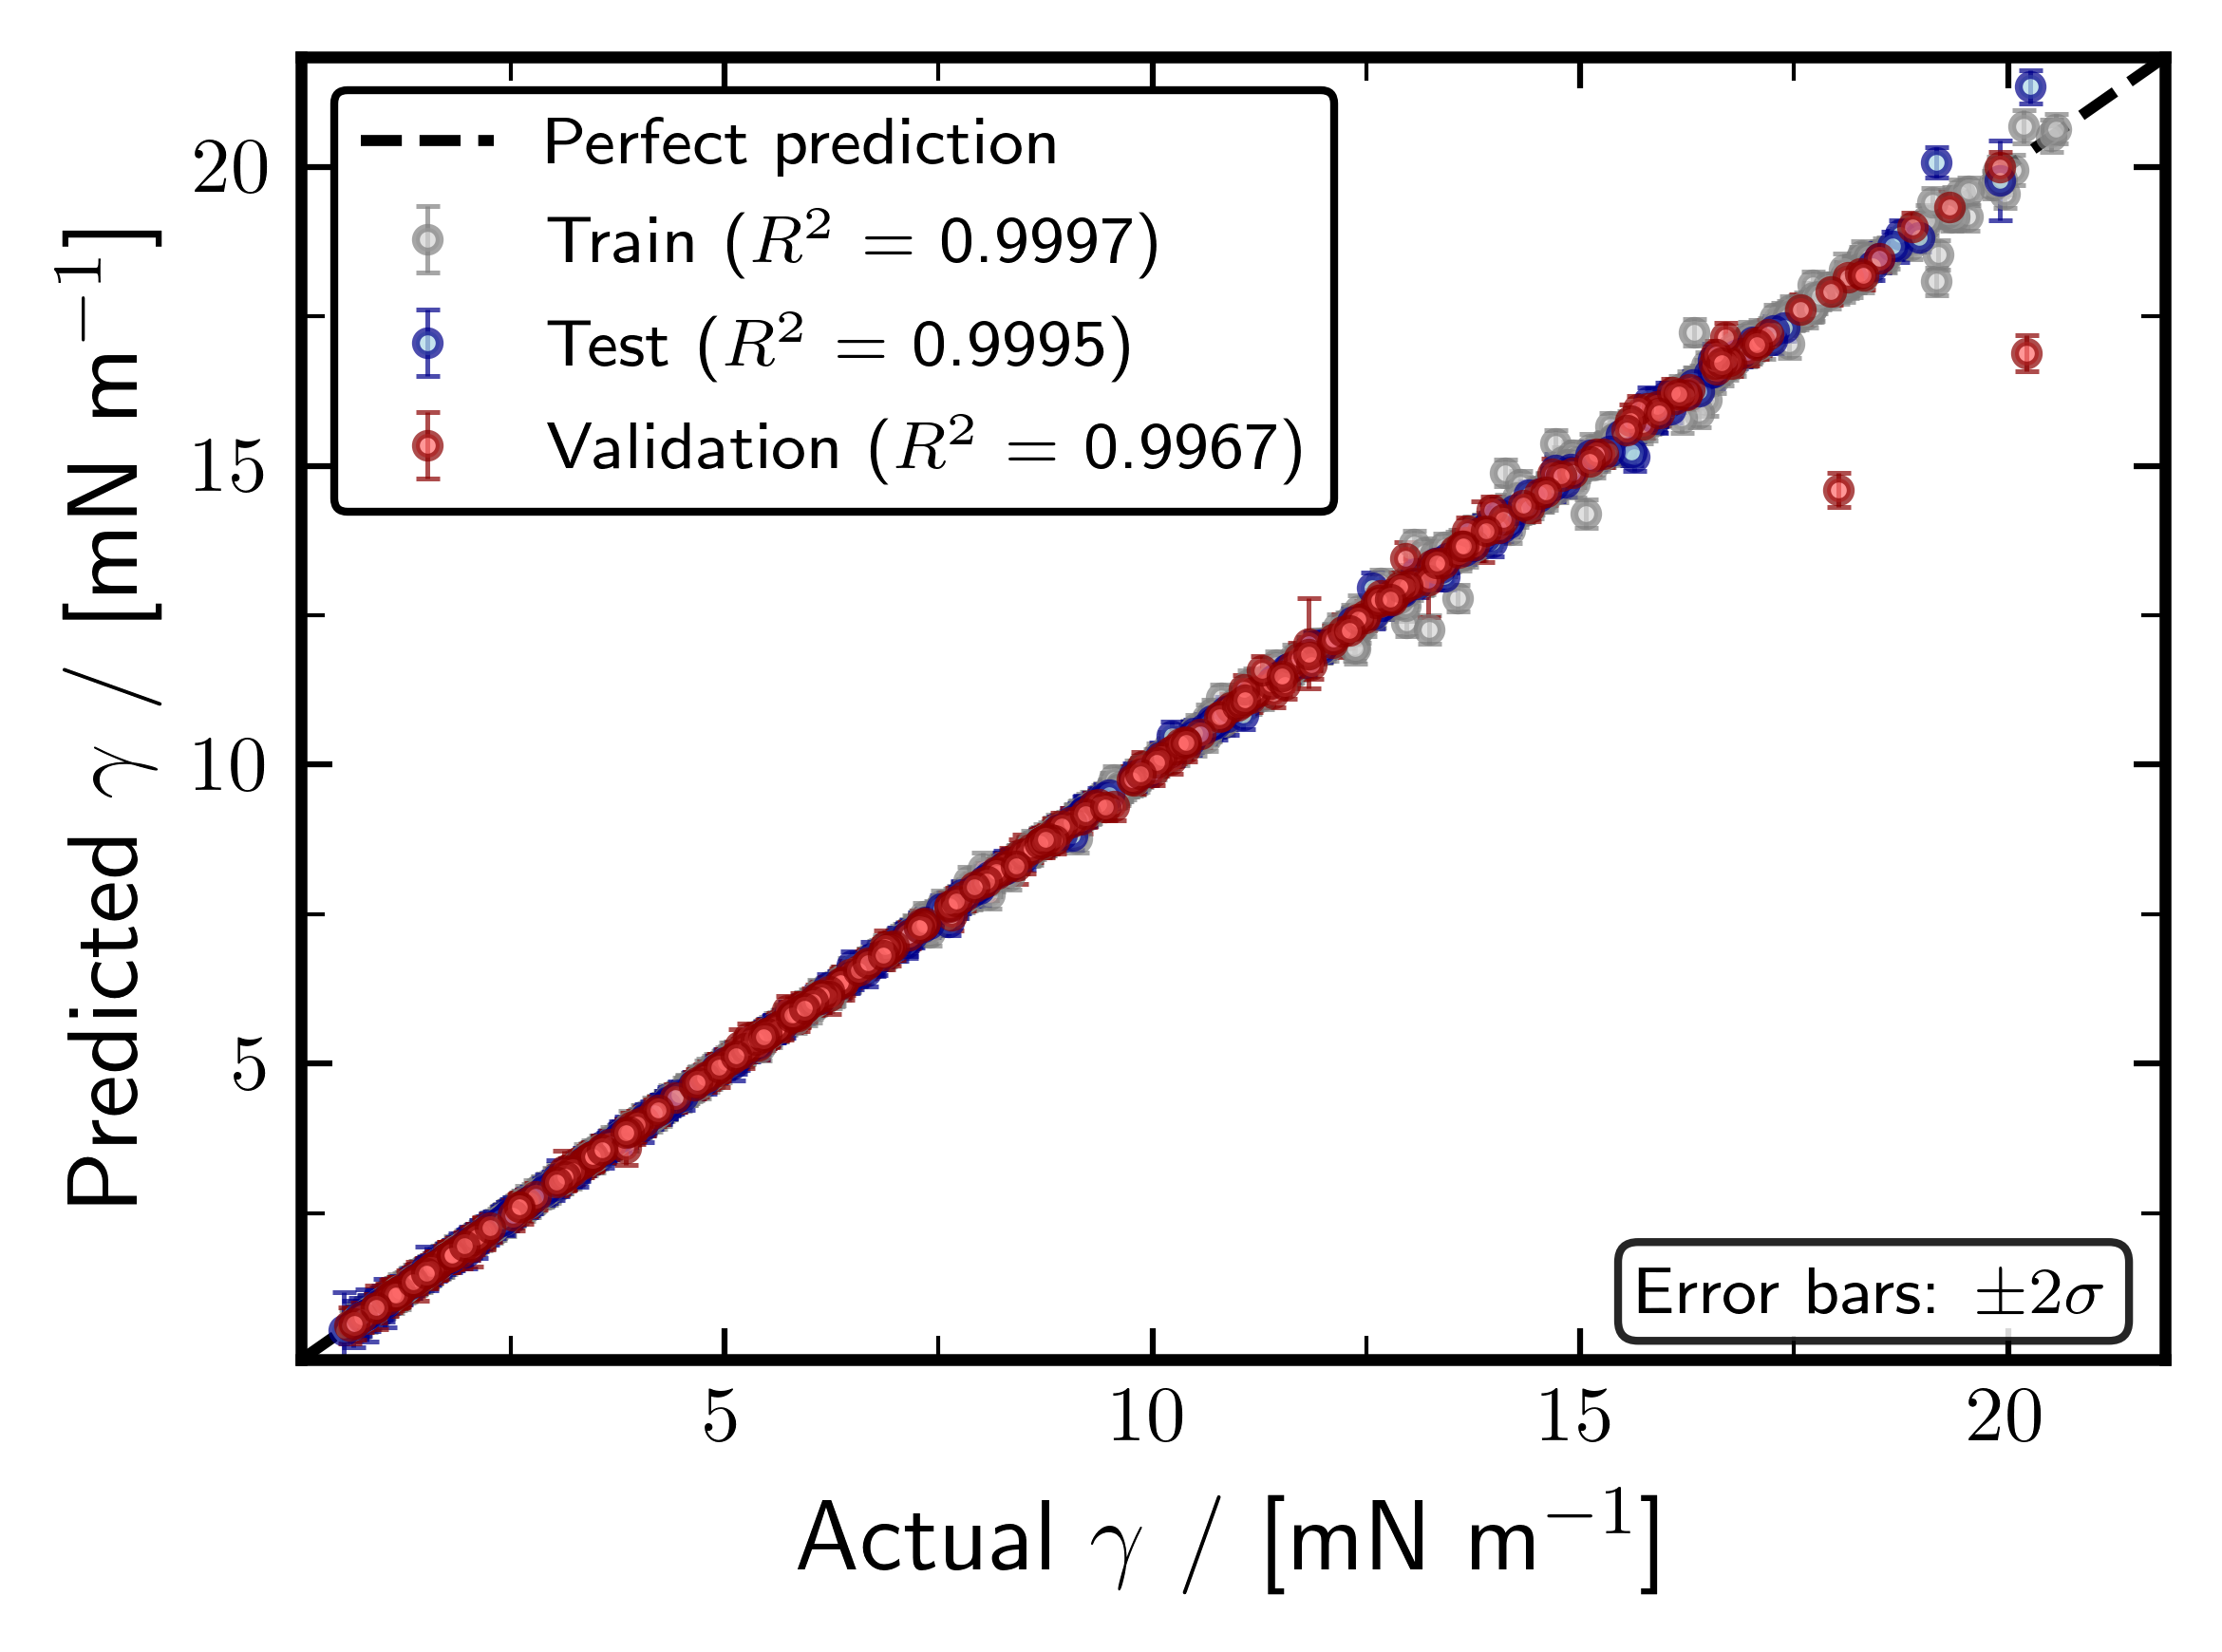

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $\\gamma$ / [mN m$^{-1}$]', ylabel='Predicted $\\gamma$ / [mN m$^{-1}$]'>)

In [20]:
# Parity plot: gamma_cDFT (actual) vs gamma_pred (reconstructed) with ±2σ uncertainty
post.plot_reconstructed_parity(
    datasets_reconstructed={
        "train": (gamma_cDFT_train, gamma_pred_train, y_train_std),
        "test":  (gamma_cDFT_test,  gamma_pred_test,  y_test_std),
        "val":   (gamma_cDFT_val,   gamma_pred_val,   y_val_std),
    },
    n_sigma=2.0,
    model_name="GPR",
    save_path="GPR_gamma_reconstructed_parity",
    folder=OUTPUT_FOLDER,
)

In [21]:
# post.print_summary()

# # Collect and save all metrics
# metrics["cv_r2_scores"]   = cv_r2_scores.tolist()
# metrics["cv_r2_mean"]     = float(cv_r2_scores.mean())
# metrics["cv_r2_std"]      = float(cv_r2_scores.std())
# metrics["cv_rmse_scores"] = cv_rmse_scores.tolist()
# metrics["cv_rmse_mean"]   = float(cv_rmse_scores.mean())
# metrics["cv_rmse_std"]    = float(cv_rmse_scores.std())
# metrics["model"]          = "SVR_linear"
# metrics["kernel"]         = svm_model.named_steps["svr"].kernel
# metrics["C"]              = svm_model.named_steps["svr"].C
# metrics["epsilon"]        = svm_model.named_steps["svr"].epsilon
# metrics["features"]       = features
# metrics["target"]         = target
# metrics["seed"]           = SEED

# os.makedirs(OUTPUT_FOLDER, exist_ok=True)
# metrics_path = os.path.join(OUTPUT_FOLDER, f"SVM_{target}_metrics.json")
# with open(metrics_path, "w") as f:
#     json.dump(metrics, f, indent=2, default=str)

# print(f"\nMetrics saved to: {metrics_path}")

In [22]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 5.96 minutes
